# FIRST NOTEBOOK: RQ1 - Assessing the Predictive Value of Sibling-Topic Practice for Early Topic Success

# Research question

**RQ1:** To what extent do hierarchical relationships between topics provide evidence of transfer of learning in users’ transaction data?

More specifically, this notebook asks:

**Among active transaction-covered topics, does prior practice and performance on sibling topics improve the prediction of a user’s early success when they first enter a new target topic, beyond their general prior experience, engagement, and topic history?**

**METHOD:** For each `(user_id, child_topic_id)` pair, we identify the user’s first 3 eligible attempts on the child topic. These attempts are used to define early topic-entry success. We then compare models with and without sibling-history features to test whether previous exposure and performance on sibling topics add predictive information beyond baseline user and topic features.

**MOTIVATION:** This analysis investigates whether Lernnavi’s topic hierarchy reflects meaningful learning relationships. If prior sibling-topic practice helps predict early success in a new topic, this may suggest some transfer of learning between related topics. Such evidence could help Lernnavi improve prerequisite recommendations, guide students toward more appropriate practice paths, and avoid moving students into new topics too early.

The goal is therefore not to prove a causal effect, but to evaluate whether sibling-topic history provides useful predictive evidence of learning transfer in the transaction data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

DATA_DIR = './Lernnavi'

transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))
topic_trees = pd.read_csv('{}/topic_trees.csv.gz'.format(DATA_DIR))
topics = pd.read_csv('{}/topics_translated.csv'.format(DATA_DIR))

# Important conclusions from data exploration

- The dataset contains a curriculum organized in a tree with parent and child topics, provided by `topic_trees`.
- Topics cover two subjects, German and Math, tracked by the `math` flag.
- Only 76 of the initial topics appear in the transaction logs, corresponding to 1,268,894 transactions before the final sibling-topic filtering.
- Among these active topics, 73 have at least one active sibling, forming 14 sibling groups and representing 1,262,244 transactions before removing unanswered attempts.
- German topics have more interactions than Math topics overall.
- User trajectories are sparse: many users interact with only a small number of topics or active weeks.

The dataset is therefore suitable for studying whether sibling-topic history adds predictive information, but the analysis only covers the active transaction-covered part of the curriculum.

# 1) Data cleaning and preprocessing

**a) Defining the study universe**

The study universe is restricted to topics that are:

- valid topics only *(in the dataset description pdf, they say some topics have messages in their "description" that explicitly say they are unusable/deleted etc, so we remove them)*
- connected to the clean hierarchy *(we verify they appear in `topic_tree`)*
- active in the transactions table
- non-root topics *(we remove the roots "german" and "maths")*
- topics with at least one active sibling

**b) Target definition and design choices**

- We define "entering a new child topic" by the correctness score on the first 3 submitted answers for each `(user_id, child_topic_id)` pair *(this is less noisy than using only the accuracy on the 1st answer)*
- The variable used is `evaluation` (with the following possible values: CORRECT / WRONG / PARTIAL / NaN). We keep only `CORRECT` and `WRONG` answers. Missing evaluations and `PARTIAL` are excluded because partial score may depend on the question format (some question formats naturally allow partial credit but others do not) and is harder to compare consistently, which could mix learning signal with artifact from the question format.
- The possible classes of the target are therefore "0/3", "1/3", "2/3" or "3/3" correct answers on the first 3 answered questions per user-topic pair. However, we observe that the distribution is very imbalanced and "0/3" is very rare, as it only represents 3.6% among all classes. Therefore, we merge "0/3" and "1/3" scores into a "difficulty" class, keep "2/3" as "moderate success" and keep "3/3" as "strong success". This gives a 3-class ordinal target.
- entry_target_df : is the target-level table with one row per (`user_id`, `child_topic_id`) entry event.

**c) Cleaning the universe**

We exclude:

- transactions with topic_id = NaN *(they are not answered questions)*
- challenge activity is checked after topic filtering, but no challenge activity remains in the retained transaction universe so no need to explicitly remove any challence activity *(the analysis focuses on "normal" learning activity so we do not want challenge activity)*.
- transactions with missing `commit_time` *(because these attempts were not submitted and therefore have no usable correctness outcome)*
- user-topic pairs with less than 3 answered questions.

The first 3 submitted answers are selected by ordering attempts within each user-topic pair chronologically using `commit_time`, with `start_time` used as a secondary ordering variable.

**d) Building the hierarchical mapping**

Each active child topic is mapped to its parent and sibling set in a lookup table containing:

- `child_topic_id`
- `parent_id`
- `child_name`
- `parent_name`
- `sibling_topic_ids`

This lookup table is then used to compute prior sibling-topic exposure.

In [2]:
# a) Define the study universe

# 1) keep valid topic only -> delete topics with messages in the description column containing the words: "deleted" "delete" "error" or "mistake"
print("------ VALID TOPIC SELECTION ------")
# Replace NaN description by empty comment (they are kept because it does not mean the topic is invalid)
topics["description"] = topics["description"].fillna("").str.strip()

# Regex patterns for invalid topics
invalid_patterns = [
    r"\bdelete?\b",      
    r"\bdeleted?\b",    
    r"\berror\b",   
    r"\bmistake\b",  
    r"\binvalid\b"  
]

invalid_regex = "|".join(invalid_patterns)

# New column created: is invalid -> flag invalid topics with "True" value in this new column
topics["is_invalid"] = topics["description"].str.lower().str.contains(
    invalid_regex,
    regex=True,
    na=False
)

# keep only the valid topics in a new table valid_topics
valid_topics = topics.loc[~topics["is_invalid"]].copy()

print("Number of invalid topics detected:", topics["is_invalid"].sum())
print("Number of valid topics:", len(valid_topics))

# 2) keep only topics present in the tree
print("------ ONLY KEEP TOPICS PRESENT IN TH TREE ------")
# only keep valid topics that were found before on topics table from the topic_trees file also
mask_valid_hierarchy = (
    topic_trees["child_id"].isin(set(valid_topics["id"]))
    & (topic_trees["parent_id"].isna() | topic_trees["parent_id"].isin(set(valid_topics["id"])))
)

tree_valid = topic_trees.loc[mask_valid_hierarchy].copy() # cleaned hierarchy table
valid_topics_in_tree = set(tree_valid["child_id"].dropna().astype(int)).union(set(tree_valid["parent_id"].dropna().astype(int))) # cleaned set of topics present in the tree_valid table

print("Rows kept in valid hierarchy:", len(tree_valid))
print("Rows removed because child or parent topic was invalid:", len(topic_trees) - len(tree_valid))
print("Unique valid topics represented in the hierarchy:", len(valid_topics_in_tree))

# remove those missing topic in tree from the valid topics list
valid_topics = valid_topics[valid_topics["id"].isin(valid_topics_in_tree)].copy()
print("Number of usable valid topics after filtering:", valid_topics["id"].nunique())

# 3) keep only topics that appear in the transactions table
print("------ ONLY KEEP THE TOPICS THAT APPEAR IN THE TRANSACTIONS ------")
valid_topic_ids = set(valid_topics["id"].dropna().astype(int))

# keep only transactions on usable valid topics
transactions = transactions[transactions["topic_id"].isin(valid_topic_ids)].copy()
topics_seen_in_transactions = set(transactions["topic_id"].dropna().astype(int))

print("Transactions kept on usable valid topics:", len(transactions))
print("Number of usable valid topics represented in transactions:", transactions["topic_id"].nunique())

# remove those topics that never appear in the transactions table from the valid topics list
valid_topics = valid_topics[valid_topics["id"].isin(topics_seen_in_transactions)].copy()
valid_topic_ids = set(valid_topics["id"].dropna().astype(int))

print("Number of valid topics remaining after keeping only those seen in transactions:", valid_topics["id"].nunique())

# 4) keep only topics with at least one active sibling (which also removes root topics "german" and "maths")
print("------ KEEP ONLY TOPICS WITH AT LEAST 1 ACTIVE SIBLING ------")
child_parent = tree_valid[["child_id", "parent_id"]].drop_duplicates().copy()
child_parent["child_id"] = pd.to_numeric(child_parent["child_id"], errors="coerce")
child_parent["parent_id"] = pd.to_numeric(child_parent["parent_id"], errors="coerce")

# keep only active topics in the hierarchy
child_parent = child_parent[child_parent["child_id"].isin(valid_topic_ids)].copy()

# number of active children per parent
n_active_children = child_parent[child_parent["parent_id"].notna()].groupby("parent_id")["child_id"].nunique()

# topics whose parent has at least 2 active children (= at least one active sibling)
topics_with_active_siblings = set(
    child_parent.loc[
        child_parent["parent_id"].notna()
        & child_parent["parent_id"].map(n_active_children).fillna(0).ge(2),
        "child_id"
    ].astype(int)
)

# keep only those topics
valid_topics = valid_topics[valid_topics["id"].isin(topics_with_active_siblings)].copy()

# keep transactions consistent with the new topic universe (just in case)
transactions = transactions[transactions["topic_id"].isin(topics_with_active_siblings)].copy()

print("Number of active topics with at least one active sibling:", len(topics_with_active_siblings))
print("Number of valid topics remaining:", valid_topics["id"].nunique())
print("Transactions remaining:", len(transactions))

------ VALID TOPIC SELECTION ------
Number of invalid topics detected: 48
Number of valid topics: 652
------ ONLY KEEP TOPICS PRESENT IN TH TREE ------
Rows kept in valid hierarchy: 626
Rows removed because child or parent topic was invalid: 52
Unique valid topics represented in the hierarchy: 633
Number of usable valid topics after filtering: 633
------ ONLY KEEP THE TOPICS THAT APPEAR IN THE TRANSACTIONS ------
Transactions kept on usable valid topics: 1268894
Number of usable valid topics represented in transactions: 76
Number of valid topics remaining after keeping only those seen in transactions: 76
------ KEEP ONLY TOPICS WITH AT LEAST 1 ACTIVE SIBLING ------
Number of active topics with at least one active sibling: 73
Number of valid topics remaining: 73
Transactions remaining: 1262244


In [3]:
# b) cleaning the universe

# Make sure timestamps are datetime
transactions["start_time"] = pd.to_datetime(transactions["start_time"], errors="coerce")
transactions["commit_time"] = pd.to_datetime(transactions["commit_time"], errors="coerce")

# are there challenge activities remaining?
n_challenge = (transactions["challenge"] == True).sum()

# how many users have at least one missing timestamp?
users_missing_timestamps = transactions.loc[
    transactions["start_time"].isna() | transactions["commit_time"].isna(),
    "user_id"
].nunique()

users_missing_starttime= transactions.loc[
    transactions["start_time"].isna(),
    "user_id"
].nunique()

print("Challenge activities in remaining transactions:", n_challenge)
print("Users with missing start time:", users_missing_starttime)
print("Users with missing timestamps:", users_missing_timestamps) # those are task attempts that were started but never submitted (this represents 79,466 rows across 17,369 users) -> for this research question we need only answered question

# Remove transactions with missing timestamps
transactions = transactions[transactions["commit_time"].notna()].copy()
print("Remaining number of transactions after filtering pipeline:", len(transactions))

Challenge activities in remaining transactions: 0
Users with missing start time: 0
Users with missing timestamps: 17369
Remaining number of transactions after filtering pipeline: 1182778


The filtering pipeline reduces the topic universe from 700 topics to **73 active topics** with at least one active sibling. The retained universe is therefore appropriate for the research question, although it only represents the active part of the curriculum rather than the full Lernnavi topic tree.

17,369 users have at least one transaction with a missing `commit_time` (no `start_time` is missing). These rows correspond to attempts that were started but not submitted, so they cannot be used to compute correctness-based targets or features. Therefore, the corresponding transactions are removed, but the users themselves are not necessarily removed if they have other valid submitted attempts.

After filtering, **1,182,778 transactions** remain.

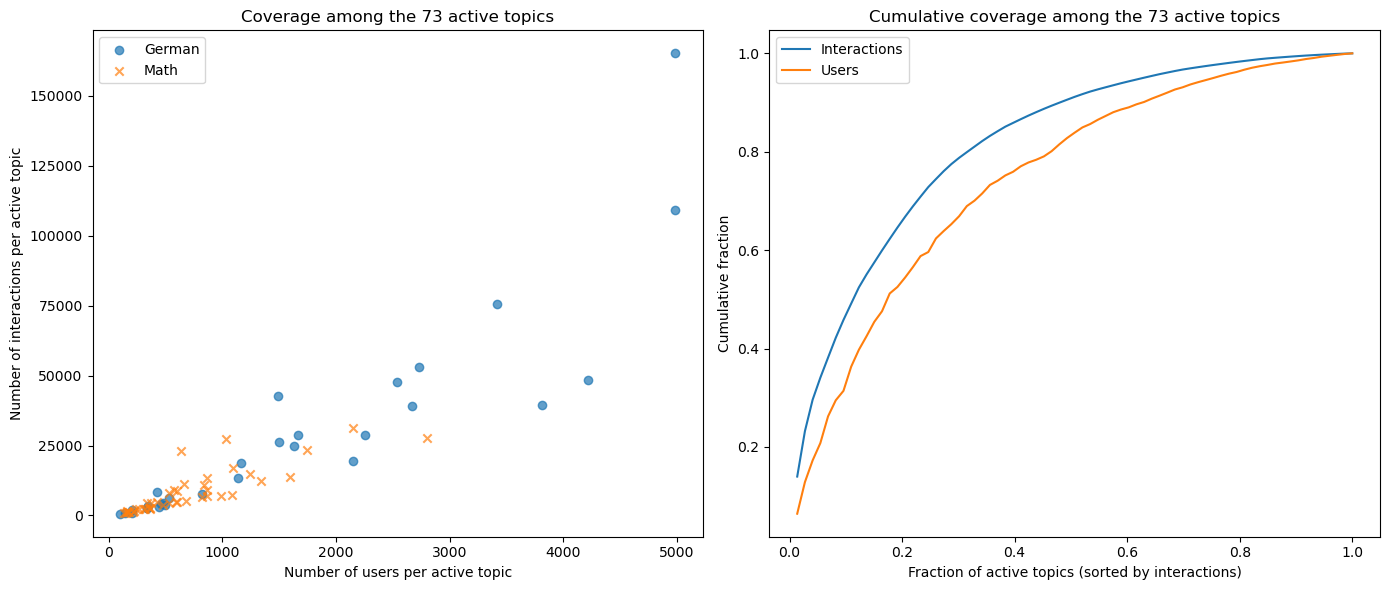

In [4]:
# VISUALIZATION: coverage among the remaining 73 topics

# prepare data
topic_user_stats_active = (
    transactions.groupby("topic_id")
    .agg(
        n_interactions=("topic_id", "size"),
        n_users=("user_id", "nunique")
    )
    .reset_index()
    .merge(
        valid_topics[["id", "name", "math"]],
        left_on="topic_id",
        right_on="id",
        how="left"
    )
    .drop(columns="id")
    .sort_values("n_interactions", ascending=False)
    .reset_index(drop=True)
)

coverage_curve_active = topic_user_stats_active.copy()
coverage_curve_active["topic_rank"] = np.arange(1, len(coverage_curve_active) + 1)

coverage_curve_active["cum_interactions"] = coverage_curve_active["n_interactions"].cumsum()
coverage_curve_active["cum_users"] = coverage_curve_active["n_users"].cumsum()

coverage_curve_active["cum_interactions_frac"] = (
    coverage_curve_active["cum_interactions"] / coverage_curve_active["n_interactions"].sum()
)
coverage_curve_active["cum_users_frac"] = (
    coverage_curve_active["cum_users"] / coverage_curve_active["n_users"].sum()
)
coverage_curve_active["topic_frac"] = (
    coverage_curve_active["topic_rank"] / len(coverage_curve_active)
)

# Create one figure with 2 panels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_df = topic_user_stats_active.copy()
for m, label, marker in [(0, "German", "o"), (1, "Math", "x")]:
    subset = plot_df[plot_df["math"] == m]
    axes[0].scatter(
        subset["n_users"],
        subset["n_interactions"],
        alpha=0.7,
        label=label,
        marker=marker
    )

axes[0].set_xlabel("Number of users per active topic")
axes[0].set_ylabel("Number of interactions per active topic")
axes[0].set_title("Coverage among the 73 active topics")
axes[0].legend()

axes[1].plot(
    coverage_curve_active["topic_frac"],
    coverage_curve_active["cum_interactions_frac"],
    label="Interactions"
)
axes[1].plot(
    coverage_curve_active["topic_frac"],
    coverage_curve_active["cum_users_frac"],
    label="Users"
)

axes[1].set_xlabel("Fraction of active topics (sorted by interactions)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Cumulative coverage among the 73 active topics")
axes[1].legend()

plt.tight_layout()
plt.show()

**IMPORTANT CONCLUSION FROM THESE PLOTS:** Some topics are very well represented (lots of users have answered questions associated with these topics and/or many questions from these topics were answered) and will contribute a lot to the model, while others are very sparse. The model will therefore learn much more reliably on the large topics and performance on small topics may be unstable. This justifies including `child_topic_id` as a baseline feature to control for topic-specific difficulty and coverage effects.

Number of CORRECT transactions: 490366
Number of WRONG transactions: 125496


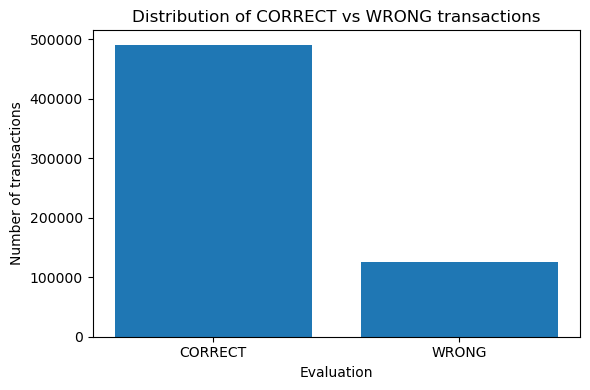

In [5]:
# c) Target variable

# Keep only rows with a strict outcome (either CORRECT or WRONG, we exclude NaNs and PARTIAL answers)
transactions = transactions[transactions["evaluation"].isin(["CORRECT", "WRONG"])].copy()

# binary target column
transactions["target"] = (transactions["evaluation"] == "CORRECT").astype(int)

# Print total number of transactions for each class
class_counts = transactions["evaluation"].value_counts()
print("Number of CORRECT transactions:", class_counts.get("CORRECT", 0))
print("Number of WRONG transactions:", class_counts.get("WRONG", 0))

# Plot distribution of each class
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Evaluation")
plt.ylabel("Number of transactions")
plt.title("Distribution of CORRECT vs WRONG transactions")
plt.tight_layout()
plt.show()

After removing PARTIAL and NaN evaluations, the retained transactions are highly imbalanced:

- **490,366 CORRECT** (79.6%)
- **125,496 WRONG** (20.4%).

This strong skew toward correct answers is typical of adaptive platforms where students tend to practice content they can already partially handle.

In [6]:
# Reorder the dataset and define what is the "first attempts in a new child topics"

# FIRST I NEED TO VERIFY WE CAN DEFINE "ENTERING A NEW CHILD TOPIC" AS THE CORRECTNESS SCORE OF THE FIRST 3 ANSWERED QUESTIONS
# Count answered questions per user per child topic
user_topic_counts = (
    transactions.groupby(["user_id", "topic_id"])
    .size()
    .reset_index(name="n_answered_questions")
)

# distribution of number of answered questions per user-topic pair
print("\nSummary of answered questions per user-topic pair:")
print(user_topic_counts["n_answered_questions"].describe())

# keep user-topic pairs with at least 3 answered questions and check there are enough pairs remaining
user_topic_3plus = user_topic_counts[user_topic_counts["n_answered_questions"] >= 3].copy()

print("Number of user-topic pairs:", len(user_topic_counts))
print("Number of user-topic pairs with at least 3 answered questions:", len(user_topic_3plus))
print("Proportion:", len(user_topic_3plus) / len(user_topic_counts))

# okay let's keep the first 3 questions which is robust to describe an "entry phase" into a subject
# we merge 0/3 and 1/3 as "the student is not entering the topic smoothly and seems to have real difficulty early on" and keep 2/3 (moderate success) and 3/3 (strong success) options => 3 classes

# Keep only the columns we need and sort chronologically within each (user, topic) pair
tx_target = transactions.copy()
sort_cols = [c for c in ["user_id", "topic_id", "commit_time", "start_time", "transaction_id"] if c in tx_target.columns]
tx_target = tx_target.sort_values(sort_cols).copy()

# Rank answered questions within each (user_id, child_topic_id) pair
tx_target["question_rank_in_topic"] = tx_target.groupby(["user_id", "topic_id"]).cumcount() + 1

# Keep only the first 3 answered questions per (user_id, child_topic_id)
tx_first3 = tx_target[tx_target["question_rank_in_topic"] <= 3].copy()

# Aggregate to one row per (user_id, child_topic_id)
entry_target_df = (
    tx_first3.groupby(["user_id", "topic_id"], as_index=False)
    .agg(
        n_first_questions=("evaluation", "size"),
        n_correct_first3=("evaluation", lambda s: (s == "CORRECT").sum()),
        first_start_time=("start_time", "min"),
        first_commit_time=("commit_time", "min")
    )
)

# keep only user-topic pairs with at least 3 answered questions, and keep only the answers to the first 3 questions
entry_target_df = entry_target_df[entry_target_df["n_first_questions"] == 3].copy()

# Define the target classes
# difficulty = 0/3 or 1/3 correct
# moderate_success = 2/3 correct
# strong_success = 3/3 correct
entry_target_df["target_class"] = np.select(
    [entry_target_df["n_correct_first3"].isin([0, 1]), entry_target_df["n_correct_first3"] == 2, entry_target_df["n_correct_first3"] == 3],
    ["difficulty", "moderate_success", "strong_success"],
    default="unknown"
)

# numeric encoding of classes for modeling
target_map = {
    "difficulty": 0,
    "moderate_success": 1,
    "strong_success": 2
}
entry_target_df["target_code"] = entry_target_df["target_class"].map(target_map)


print("Number of user-topic pairs kept in the final target table:", len(entry_target_df))
print("\nTarget distribution:")
print(entry_target_df["target_class"].value_counts())
print("\nTarget proportions:")
print(entry_target_df["target_class"].value_counts(normalize=True))

display(entry_target_df.head(20))


Summary of answered questions per user-topic pair:
count    67711.000000
mean         9.095450
std         34.319466
min          1.000000
25%          2.000000
50%          5.000000
75%         10.000000
max       6930.000000
Name: n_answered_questions, dtype: float64
Number of user-topic pairs: 67711
Number of user-topic pairs with at least 3 answered questions: 49735
Proportion: 0.7345187635686964
Number of user-topic pairs kept in the final target table: 49735

Target distribution:
target_class
strong_success      26309
moderate_success    15565
difficulty           7861
Name: count, dtype: int64

Target proportions:
target_class
strong_success      0.528984
moderate_success    0.312959
difficulty          0.158058
Name: proportion, dtype: float64


,user_id,topic_id,n_first_questions,n_correct_first3,first_start_time,first_commit_time,target_class,target_code
0,387604,3.0,3,2,2021-09-01 07:23:37.360,2021-09-01 07:23:53.904000000,moderate_success,1
2,387604,2055.0,3,2,2022-03-21 09:59:59.304,2022-03-21 10:00:04.163000064,moderate_success,1
3,387604,2064.0,3,3,2022-08-23 10:55:57.570,2022-08-23 10:56:19.006000128,strong_success,2
4,387604,2065.0,3,3,2022-08-30 10:56:18.126,2022-08-30 10:56:45.919000064,strong_success,2
5,387604,3113.0,3,3,2022-05-11 13:02:48.592,2022-05-11 13:03:21.601999872,strong_success,2
6,387604,3156.0,3,3,2022-05-11 12:39:31.001,2022-05-11 12:40:32.768999936,strong_success,2
8,387604,3250.0,3,1,2022-03-30 11:26:59.620,2022-03-30 11:27:59.465999872,difficulty,0
9,387605,3.0,3,3,2021-09-05 03:35:49.950,2021-09-05 03:36:03.064000000,strong_success,2
11,387605,956.0,3,1,2021-09-05 03:17:41.084,2021-09-05 03:17:55.377999872,difficulty,0
12,387605,957.0,3,1,2022-05-10 06:57:41.153,2022-05-10 06:58:34.694000128,difficulty,0


In [7]:
# Final modeling data summary
print("Final modeling dataframe shape:", entry_target_df.shape)
print("Number of entry events (rows):", len(entry_target_df))
print("Number of unique users:", entry_target_df["user_id"].nunique())

print("\nTarget proportions:")
print(entry_target_df["target_class"].value_counts(normalize=True))

print("\nRows per child topic:")
print(entry_target_df.groupby("topic_id").size().describe())

print("\nRows per user:")
print(entry_target_df.groupby("user_id").size().describe())

Final modeling dataframe shape: (49735, 8)
Number of entry events (rows): 49735
Number of unique users: 14938

Target proportions:
target_class
strong_success      0.528984
moderate_success    0.312959
difficulty          0.158058
Name: proportion, dtype: float64

Rows per child topic:
count      73.000000
mean      681.301370
std       822.954445
min        17.000000
25%       170.000000
50%       397.000000
75%       804.000000
max      3986.000000
dtype: float64

Rows per user:
count    14938.000000
mean         3.329428
std          3.464680
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         40.000000
dtype: float64


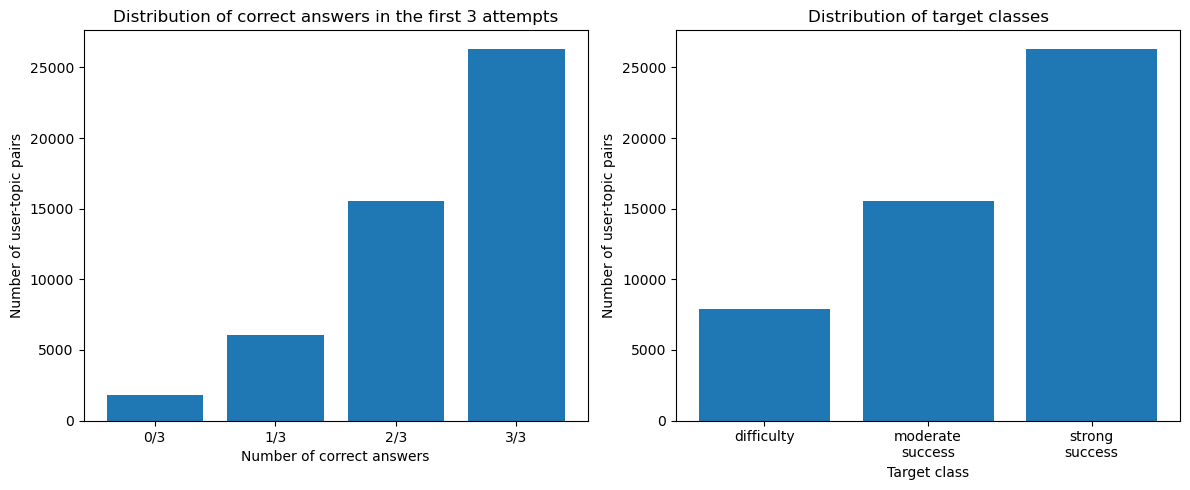

In [8]:
# count distribution of number of correct answers among the first 3
counts_first3 = (
    entry_target_df["n_correct_first3"]
    .value_counts()
    .reindex([0, 1, 2, 3], fill_value=0)
)

# count distribution of target classes
class_order = ["difficulty", "moderate_success", "strong_success"]
counts_classes = (
    entry_target_df["target_class"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

# create one figure representing both distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(
    ["0/3", "1/3", "2/3", "3/3"],
    counts_first3.values
)
axes[0].set_title("Distribution of correct answers in the first 3 attempts")
axes[0].set_xlabel("Number of correct answers")
axes[0].set_ylabel("Number of user-topic pairs")

axes[1].bar(
    ["difficulty", "moderate\nsuccess", "strong\nsuccess"],
    counts_classes.values
)
axes[1].set_title("Distribution of target classes")
axes[1].set_xlabel("Target class")
axes[1].set_ylabel("Number of user-topic pairs")

plt.tight_layout()
plt.show()

Of the 67,711 user-topic pairs, 73.5% have at least 3 answered questions, yielding **49,735 entry events from 14,938 users** in the final target table.

The target is imbalanced and skewed toward success:

- **52.9%** of entries are **strong success**: 3/3 correct;
- **31.3%** are **moderate success**: 2/3 correct;
- **15.8%** are **difficulty**: 0/3 or 1/3 correct.

This skew is consistent with the high overall correctness rate observed above and motivates the use of class-balanced sample weights during model training. The 0/3 class is very small on its own, so 0/3 and 1/3 are grouped into a broader “difficulty” class. This creates a more stable low-performance class while preserving the ordinal interpretation of early topic-entry performance.

Per user, the median number of retained entry events is only 2, highlighting the sparse nature of user trajectories.

In [40]:
print(counts_first3)

n_correct_first3
0     1777
1     6084
2    15565
3    26309
Name: count, dtype: int64


In [10]:
# d) Create a lookup table to map each active child topic to its parent_id and sibling set

# prepare a clean hierarchy restricted to the final retained topics
active_topic_ids = set(valid_topics["id"].dropna().astype(int))

hier_active = tree_valid.copy()
hier_active["child_id"] = pd.to_numeric(hier_active["child_id"], errors="coerce")
hier_active["parent_id"] = pd.to_numeric(hier_active["parent_id"], errors="coerce")

# keep only rows whose child is one of the final active topics
hier_active = hier_active[hier_active["child_id"].isin(active_topic_ids)].copy()

print("Rows in tree_valid:", len(tree_valid))
print("Rows in active hierarchy:", len(hier_active))
print("Unique active child topics in hierarchy:", hier_active["child_id"].nunique())
print("Unique active topics in valid_topics:", valid_topics["id"].nunique())

# add topic names
topic_lookup = topics[topics["id"].isin(valid_topics_in_tree)][["id", "name"]].drop_duplicates()

child_parent_named = (
    hier_active[["child_id", "parent_id"]]
    .drop_duplicates()
    .merge(
        topic_lookup.rename(columns={"id": "child_id", "name": "child_name"}),
        on="child_id",
        how="left"
    )
    .merge(
        topic_lookup.rename(columns={"id": "parent_id", "name": "parent_name"}),
        on="parent_id",
        how="left"
    )
)

# build sibling sets from shared parent
siblings_by_parent = (
    child_parent_named.groupby("parent_id")["child_id"]
    .apply(lambda s: sorted(s.dropna().astype(int).unique().tolist()))
    .reset_index(name="all_children_of_parent")
)

lookup_table = child_parent_named.merge(siblings_by_parent, on="parent_id", how="left")

# remove the child itself from its sibling set
lookup_table["sibling_topic_ids"] = lookup_table.apply(
    lambda row: [tid for tid in row["all_children_of_parent"] if tid != row["child_id"]],
    axis=1
)

lookup_table["n_active_siblings"] = lookup_table["sibling_topic_ids"].apply(len)

lookup_table = lookup_table[
    ["child_id", "parent_id", "child_name", "parent_name", "sibling_topic_ids", "n_active_siblings"]
].rename(columns={
    "child_id": "child_topic_id"
})

print("\nLookup table rows:", len(lookup_table))

display(lookup_table.head(20))

Rows in tree_valid: 626
Rows in active hierarchy: 73
Unique active child topics in hierarchy: 73
Unique active topics in valid_topics: 73

Lookup table rows: 73


,child_topic_id,parent_id,child_name,parent_name,sibling_topic_ids,n_active_siblings
0,3,2.0,Spelling principles,Orthography,"[2055, 2064, 2065]",3
1,2055,2.0,Upper and lower case,Orthography,"[3, 2064, 2065]",3
2,2064,2.0,Separation and combination,Orthography,"[3, 2055, 2065]",3
3,2065,2.0,Spelling difficult words,Orthography,"[3, 2055, 2064]",3
4,2023,2022.0,Vocabulary,Vocabulary and stylistics,"[2042, 2045, 2048]",3
5,2042,2022.0,Idiomatisms,Vocabulary and stylistics,"[2023, 2045, 2048]",3
6,2045,2022.0,Rhetoric,Vocabulary and stylistics,"[2023, 2042, 2048]",3
7,2048,2022.0,Stylistic appropriateness,Vocabulary and stylistics,"[2023, 2042, 2045]",3
8,951,950.0,Number sets,Numbers and number sets,"[952, 956, 957, 958, 962, 963, 964, 968]",8
9,952,950.0,Fractions - basic arithmetic operations,Numbers and number sets,"[951, 956, 957, 958, 962, 963, 964, 968]",8


In [11]:
# set of child topics in the final lookup table
child_topic_ids = set(lookup_table["child_topic_id"].dropna().astype(int))

# set of parent topics in the final lookup table
parent_topic_ids = set(lookup_table["parent_id"].dropna().astype(int))

# parents that are also child topics
parents_also_children = parent_topic_ids.intersection(child_topic_ids)

print("Number of unique parent topics in the final lookup table:", len(parent_topic_ids))
print("Number of parent topics that are also child topics:", len(parents_also_children))

Number of unique parent topics in the final lookup table: 14
Number of parent topics that are also child topics: 0


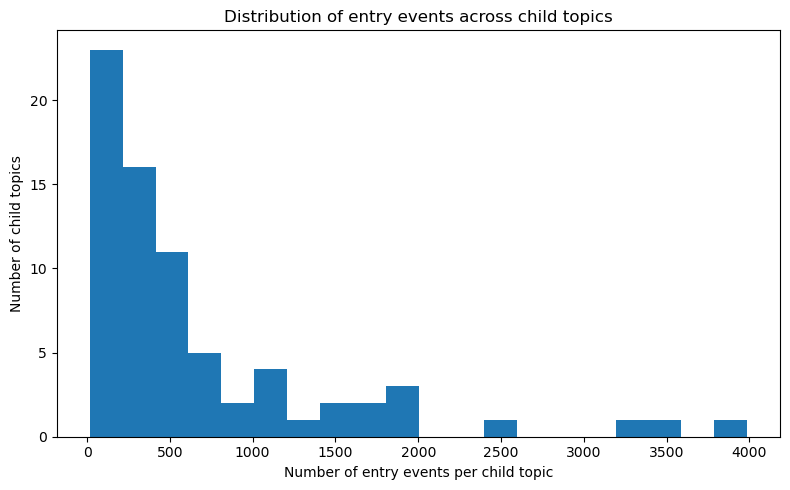

In [12]:
# visu: number of entry events and/or users per child topic

entry_plot_df = entry_target_df.rename(columns={"topic_id": "child_topic_id"}).copy()

# Count entry events per child topic
entry_counts = (
    entry_plot_df.groupby("child_topic_id")
    .size()
    .reset_index(name="n_entry_events")
    .merge(
        lookup_table[["child_topic_id", "child_name", "parent_name"]],
        on="child_topic_id",
        how="left"
    )
    .sort_values("n_entry_events", ascending=False)
)

# Histogram of entry-event counts across child topics
plt.figure(figsize=(8, 5))
plt.hist(entry_counts["n_entry_events"], bins=20)
plt.xlabel("Number of entry events per child topic")
plt.ylabel("Number of child topics")
plt.title("Distribution of entry events across child topics")
plt.tight_layout()
plt.show()

# 2) Feature engineering & creation of the final modeling dataframe

/!\ To avoid temporal leakage, prior-performance features are computed using the user's history before the target topic entry. Features are restricted to sibling attempts whose `commit_time` occurs strictly before the target topic `entry_start_time`, because correctness is only known after an answer is submitted. /!\


**a) Baseline features:**

to isolate the sibling-history contribution, we first try to capture the user's general prior ability, experience and activity before entering the new target topic. Therefore, the baseline model uses:

- `child_topic_id`, treated as a categorical feature (one-hot encoded);
- `subject_math`, indicating whether the child topic belongs to Math or German;
- `n_prior_answered_questions`;
- `prior_global_accuracy`;
- `n_prior_active_weeks`;
- `n_prior_topics_seen`;
- `n_prior_topics_same_subject`;
- `n_prior_answered_same_subject`;
- `prior_subject_accuracy`;
- `days_since_last_activity`;
- `days_since_last_same_subject_activity`.

These features are computed from all prior answered questions in the final 73-topic universe,not only from user-topic pairs retained in the final target table `entry_target_df`.

**b) Hierarchical features:**

**SIBLING TOPIC FEATURES:** For each target child-topic entry, we compute sibling-history features from previous attempts on sibling topics. The final hierarchical model adds the following features:

- `n_prior_sibling_attempts`;
- `prior_sibling_accuracy`;
- `days_since_last_sibling_activity`;
- `prop_siblings_seen`;
- `n_prior_sibling_attempts_30d`;
- `prior_sibling_accuracy_30d`;
- `prop_sibling_topics_entered_before`;
- `is_first_topic_in_sibling_group`;
- `prior_sibling_accuracy_last3`;
- `n_prior_sibling_attempts_last3`;
- `recent_sibling_accuracy_trend`.

The variable `n_prior_sibling_topics_seen` is computed as an intermediate variable and then used to derive `prop_siblings_seen`, but it is not included directly as a final model feature.

**PARENT-TOPIC FEATURES:** no feature related to parent-topic can be engineered since no transaction was recorded for parent topics in the raw transactions table. However, parent-topic information is still used indirectly to define sibling groups and transition features within each sibling group.

**FINAL MODELING DATAFRAME:** `entry_model_df` : contains one row per user-topic entry event, with the target class, baseline features, sibling-history features and topic-hierarchy metadata.

**Clean the modeling dataframe:** For each row, we verified the chronology to ensure it is not broken and we previously removed rows with missing target. NaN values in features are handled differently depending on the feature meaning: missing prior accuracies are set to 0, while missing recency variables are set to -1 to indicate no previous activity.

In [13]:
# BASELINE FEATURES

# 1) Prepare transaction-level table with topic metadata
tx_feat = transactions.copy() 

# add child topic metadata
tx_feat = tx_feat.merge(
    valid_topics[["id", "name", "math"]].rename(columns={
        "id": "topic_id",
        "name": "child_name",
        "math": "subject_math"
    }),
    on="topic_id",
    how="left"
)

# binary correctness for prior-accuracy features
tx_feat["is_correct"] = (tx_feat["evaluation"] == "CORRECT").astype(int)

# sort chronologically within user
sort_cols = [c for c in ["user_id", "commit_time", "start_time", "transaction_id"] if c in tx_feat.columns]
tx_feat = tx_feat.sort_values(sort_cols).copy()

# 2) Transaction-level cumulative features BEFORE each transaction

# total number of prior answered questions
tx_feat["n_prior_answered_questions"] = tx_feat.groupby("user_id").cumcount()

# global prior accuracy
tx_feat["prior_correct_sum_global"] = tx_feat.groupby("user_id")["is_correct"].cumsum() - tx_feat["is_correct"]
tx_feat["prior_global_accuracy"] = (
    tx_feat["prior_correct_sum_global"] /
    tx_feat["n_prior_answered_questions"].replace(0, np.nan)
)

# prior subject-specific experience
tx_feat["n_prior_answered_same_subject"] = tx_feat.groupby(["user_id", "subject_math"]).cumcount()

tx_feat["prior_correct_sum_same_subject"] = (
    tx_feat.groupby(["user_id", "subject_math"])["is_correct"].cumsum() - tx_feat["is_correct"]
)

tx_feat["prior_subject_accuracy"] = (
    tx_feat["prior_correct_sum_same_subject"] /
    tx_feat["n_prior_answered_same_subject"].replace(0, np.nan)
)

# recency since last platform activity
tx_feat["prev_activity_time"] = tx_feat.groupby("user_id")["start_time"].shift(1)
tx_feat["days_since_last_activity"] = (
    (tx_feat["start_time"] - tx_feat["prev_activity_time"]).dt.total_seconds() / 86400
)

# recency since last same-subject activity
tx_feat["prev_same_subject_activity_time"] = (
    tx_feat.groupby(["user_id", "subject_math"])["start_time"].shift(1)
)

tx_feat["days_since_last_same_subject_activity"] = (
    (tx_feat["start_time"] - tx_feat["prev_same_subject_activity_time"]).dt.total_seconds() / 86400
)

# Prior number of active weeks
# relative week index per user
user_week0 = tx_feat.groupby("user_id")["start_time"].transform("min")
tx_feat["week"] = ((tx_feat["start_time"] - user_week0).dt.days // 7).astype(int)

# one row per active week per user
user_week = (
    tx_feat[["user_id", "week"]]
    .drop_duplicates()
    .sort_values(["user_id", "week"])
    .copy()
)

# number of ACTIVE weeks before the current week
user_week["n_prior_active_weeks"] = user_week.groupby("user_id").cumcount()

# merge back to transactions
tx_feat = tx_feat.merge(user_week, on=["user_id", "week"], how="left")

# Prior number of previously seen topics (in general) and prior number of previously seen topics in the same subject (german vs math)

# first time each user sees each topic
first_topic_seen = (
    tx_feat.groupby(["user_id", "topic_id", "subject_math"], as_index=False)["start_time"]
    .min()
    .rename(columns={"start_time": "first_topic_seen_time"})
)

# ---- overall previously seen topics
topic_starts_overall = (
    first_topic_seen.groupby(["user_id", "first_topic_seen_time"])
    .size()
    .reset_index(name="n_new_topics_at_time")
    .sort_values(["user_id", "first_topic_seen_time"])
)

topic_starts_overall["cum_topics_seen"] = topic_starts_overall.groupby("user_id")["n_new_topics_at_time"].cumsum()
topic_starts_overall["n_prior_topics_seen"] = (
    topic_starts_overall.groupby("user_id")["cum_topics_seen"].shift(fill_value=0)
)

first_topic_seen = first_topic_seen.merge(
    topic_starts_overall[["user_id", "first_topic_seen_time", "n_prior_topics_seen"]],
    on=["user_id", "first_topic_seen_time"],
    how="left"
)

# ---- previously seen topics in the same subject (german or math)
topic_starts_same_subject = (
    first_topic_seen.groupby(["user_id", "subject_math", "first_topic_seen_time"])
    .size()
    .reset_index(name="n_new_same_subject_topics_at_time")
    .sort_values(["user_id", "subject_math", "first_topic_seen_time"])
)

topic_starts_same_subject["cum_same_subject_topics_seen"] = (
    topic_starts_same_subject.groupby(["user_id", "subject_math"])["n_new_same_subject_topics_at_time"].cumsum()
)

topic_starts_same_subject["n_prior_topics_same_subject"] = (
    topic_starts_same_subject.groupby(["user_id", "subject_math"])["cum_same_subject_topics_seen"].shift(fill_value=0)
)

first_topic_seen = first_topic_seen.merge(
    topic_starts_same_subject[["user_id", "subject_math", "first_topic_seen_time", "n_prior_topics_same_subject"]],
    on=["user_id", "subject_math", "first_topic_seen_time"],
    how="left"
)

# extract the FIRST transaction row for each (user, topic) because entry features must be measured at topic entry
first_tx_per_user_topic = (
    tx_feat
    .sort_values(["user_id", "topic_id", "commit_time", "transaction_id"])
    .drop_duplicates(["user_id", "topic_id"], keep="first")
    .rename(columns={
        "topic_id": "child_topic_id",
        "start_time": "entry_start_time",
        "commit_time": "entry_commit_time"
    })
)

# keep only the pre-entry features you want
first_tx_features = first_tx_per_user_topic[[
    "user_id",
    "child_topic_id",
    "entry_start_time",
    "entry_commit_time",
    "child_name",
    "subject_math",
    "n_prior_answered_questions",
    "prior_global_accuracy",
    "n_prior_active_weeks",
    "n_prior_answered_same_subject",
    "prior_subject_accuracy",
    "days_since_last_activity",
    "days_since_last_same_subject_activity"
]].copy()

# rename topic_id to child_topic_id for clarity
first_topic_seen = first_topic_seen.rename(columns={"topic_id": "child_topic_id"})

# for each entry event (user, child_topic) add the counts of how many topics the user had seen before entering the topic
first_tx_features = first_tx_features.merge(
    first_topic_seen[[
        "user_id",
        "child_topic_id",
        "n_prior_topics_seen",
        "n_prior_topics_same_subject"
    ]],
    on=["user_id", "child_topic_id"],
    how="left"
)

# 3) Build the final baseline features dataframe

# rename target table column for clarity
entry_model_df = entry_target_df.rename(columns={"topic_id": "child_topic_id"}).copy()

# merge lookup table (parent + siblings)
assert lookup_table["child_topic_id"].is_unique, (
    "lookup_table contains duplicated child_topic_id values. "
    "This would duplicate rows when merging."
)

entry_model_df = entry_model_df.merge(
    lookup_table,
    on="child_topic_id",
    how="left"
)

# sanity checks
assert entry_model_df["parent_id"].notna().all(), (
    "Some entry rows have no parent_id after merging lookup_table."
)
assert entry_model_df["n_active_siblings"].notna().all(), (
    "Some entry rows have missing n_active_siblings after merging lookup_table."
)

# merge basic pre-entry features
entry_model_df = entry_model_df.merge(
    first_tx_features,
    on=["user_id", "child_topic_id"],
    how="left"
)

# 4) cleanup: fill missing feature values

# missing prior accuracies mean no prior history yet -> = 0
entry_model_df["prior_global_accuracy"] = entry_model_df["prior_global_accuracy"].fillna(0)
entry_model_df["prior_subject_accuracy"] = entry_model_df["prior_subject_accuracy"].fillna(0)

# no prior activity encoded by "-1"
entry_model_df["days_since_last_activity"] = entry_model_df["days_since_last_activity"].fillna(-1)
entry_model_df["days_since_last_same_subject_activity"] = (
    entry_model_df["days_since_last_same_subject_activity"].fillna(-1)
)

for col in [
    "n_prior_answered_questions",
    "n_prior_active_weeks",
    "n_prior_topics_seen",
    "n_prior_topics_same_subject",
    "n_prior_answered_same_subject"
]:
    entry_model_df[col] = entry_model_df[col].fillna(0).astype(int)

if "child_name_x" in entry_model_df.columns and "child_name_y" in entry_model_df.columns:
    entry_model_df["child_name"] = entry_model_df["child_name_x"].fillna(entry_model_df["child_name_y"])
    entry_model_df = entry_model_df.drop(columns=["child_name_x", "child_name_y"])

# 5) final feature selection -> we will only keep these ones for the baseline model training
baseline_features_cols = [
    "child_topic_id", # treated as a categorical variable, not numerical variable!
    "subject_math",
    "n_prior_answered_questions",
    "prior_global_accuracy",
    "n_prior_active_weeks",
    "n_prior_topics_seen",
    "n_prior_topics_same_subject",
    "n_prior_answered_same_subject",
    "prior_subject_accuracy",
    "days_since_last_activity",
    "days_since_last_same_subject_activity"
]

print("Final entry_model_df shape:", entry_model_df.shape)
print(entry_model_df.columns)
display(entry_model_df[baseline_features_cols].head(20))

Final entry_model_df shape: (49735, 25)
Index(['user_id', 'child_topic_id', 'n_first_questions', 'n_correct_first3',
       'first_start_time', 'first_commit_time', 'target_class', 'target_code',
       'parent_id', 'parent_name', 'sibling_topic_ids', 'n_active_siblings',
       'entry_start_time', 'entry_commit_time', 'subject_math',
       'n_prior_answered_questions', 'prior_global_accuracy',
       'n_prior_active_weeks', 'n_prior_answered_same_subject',
       'prior_subject_accuracy', 'days_since_last_activity',
       'days_since_last_same_subject_activity', 'n_prior_topics_seen',
       'n_prior_topics_same_subject', 'child_name'],
      dtype='str')


,child_topic_id,subject_math,n_prior_answered_questions,prior_global_accuracy,n_prior_active_weeks,n_prior_topics_seen,n_prior_topics_same_subject,n_prior_answered_same_subject,prior_subject_accuracy,days_since_last_activity,days_since_last_same_subject_activity
0,3.0,0,0,0.000000,0,0,0,0,0.000000,-1.000000,-1.000000
1,2055.0,0,2,0.500000,1,1,1,2,0.500000,0.001661,0.001661
2,2064.0,0,48,0.875000,5,7,6,47,0.893617,1.139900,1.139900
3,2065.0,0,124,0.943548,6,8,7,123,0.951220,1.108403,1.108403
4,3113.0,0,14,0.714286,3,5,5,14,0.714286,0.007332,0.007332
5,3156.0,0,7,0.428571,3,3,3,7,0.428571,42.048944,42.048944
6,3250.0,0,3,0.333333,2,2,2,3,0.333333,9.060420,9.060420
7,3.0,0,57,0.736842,4,10,4,21,0.809524,0.001857,0.005326
8,956.0,1,36,0.805556,4,7,4,18,0.833333,7.466876,7.466876
9,957.0,1,77,0.792208,9,15,8,44,0.727273,34.989463,34.989463


In [14]:
# HIERARCHICAL SIBLING FEATURES

tx_hist = transactions.copy()
tx_hist["is_correct"] = (tx_hist["evaluation"] == "CORRECT").astype(int)
tx_hist = tx_hist.dropna(subset=["user_id", "topic_id", "commit_time"]).copy()
tx_hist["topic_id"] = tx_hist["topic_id"].astype(int)

# 1) building sibling-level history before each entry event

entry_siblings = entry_model_df[
    ["user_id", "child_topic_id", "entry_start_time", "sibling_topic_ids", "n_active_siblings"]
].copy()

entry_siblings = entry_siblings.explode("sibling_topic_ids").rename(
    columns={"sibling_topic_ids": "sibling_topic_id"}
)

# make sure everything is in the right format
entry_siblings["sibling_topic_id"] = pd.to_numeric(entry_siblings["sibling_topic_id"], errors="coerce")
entry_siblings = entry_siblings.dropna(subset=["sibling_topic_id"]).copy()
entry_siblings["sibling_topic_id"] = entry_siblings["sibling_topic_id"].astype(int)

# match each entry event to past transactions on sibling topics
sib_hist = entry_siblings.merge(
    tx_hist[["user_id", "topic_id", "commit_time", "is_correct"]],
    left_on=["user_id", "sibling_topic_id"],
    right_on=["user_id", "topic_id"],
    how="left"
)
# keep only transactions strictly before topic entry
sib_hist = sib_hist[sib_hist["commit_time"] < sib_hist["entry_start_time"]].copy()
sib_hist["days_before_entry"] = ((sib_hist["entry_start_time"] - sib_hist["commit_time"]).dt.total_seconds() / 86400)

# 2) overall sibling history features

sibling_features = (
    sib_hist.groupby(["user_id", "child_topic_id", "entry_start_time"], as_index=False)
    .agg(
        n_prior_sibling_attempts=("topic_id", "size"),
        prior_sibling_accuracy=("is_correct", "mean"),
        n_prior_sibling_topics_seen=("sibling_topic_id", "nunique"),
        last_sibling_activity_time=("commit_time", "max")
    )
)

# recency since last sibling activity
sibling_features["days_since_last_sibling_activity"] = (
    (sibling_features["entry_start_time"] - sibling_features["last_sibling_activity_time"]).dt.total_seconds() / 86400
)

# 3) 30 day window features

sib_hist_30d = sib_hist[sib_hist["days_before_entry"] <= 30].copy()

sibling_features_30d = (
    sib_hist_30d.groupby(["user_id", "child_topic_id", "entry_start_time"], as_index=False)
    .agg(
        n_prior_sibling_attempts_30d=("topic_id", "size"),
        prior_sibling_accuracy_30d=("is_correct", "mean")
    )
)

# 4) last 3 sibling attempts features

# Recent sibling accuracy on the last 3 sibling attempts before entry
sib_hist_last3 = (
    sib_hist.sort_values(["user_id", "child_topic_id", "entry_start_time", "commit_time"])
    .groupby(["user_id", "child_topic_id", "entry_start_time"], group_keys=False)
    .tail(3)
    .copy()
)

sibling_features_last3 = (
    sib_hist_last3.groupby(["user_id", "child_topic_id", "entry_start_time"], as_index=False)
    .agg(
        prior_sibling_accuracy_last3=("is_correct", "mean"),
        n_prior_sibling_attempts_last3=("is_correct", "size")
    )
)

# 5) merge all sibling features created  into entry_model_df
entry_model_df = entry_model_df.merge(
    sibling_features,
    on=["user_id", "child_topic_id", "entry_start_time"],
    how="left"
).merge(
    sibling_features_30d,
    on=["user_id", "child_topic_id", "entry_start_time"],
    how="left"
).merge(
    sibling_features_last3,
    on=["user_id", "child_topic_id", "entry_start_time"],
    how="left"
)

# 6) fill missing values
entry_model_df["n_prior_sibling_attempts"] = entry_model_df["n_prior_sibling_attempts"].fillna(0).astype(int)
entry_model_df["n_prior_sibling_topics_seen"] = entry_model_df["n_prior_sibling_topics_seen"].fillna(0).astype(int)
entry_model_df["prior_sibling_accuracy"] = entry_model_df["prior_sibling_accuracy"].fillna(0)
entry_model_df["days_since_last_sibling_activity"] = entry_model_df["days_since_last_sibling_activity"].fillna(-1)
entry_model_df["n_prior_sibling_attempts_30d"] = entry_model_df["n_prior_sibling_attempts_30d"].fillna(0).astype(int)
entry_model_df["prior_sibling_accuracy_30d"] = entry_model_df["prior_sibling_accuracy_30d"].fillna(0)
entry_model_df["prior_sibling_accuracy_last3"] = entry_model_df["prior_sibling_accuracy_last3"].fillna(0)
entry_model_df["n_prior_sibling_attempts_last3"] = entry_model_df["n_prior_sibling_attempts_last3"].fillna(0).astype(int)

# 7) derived sibling features

# Proportion of siblings already seen
entry_model_df["prop_siblings_seen"] = (
    entry_model_df["n_prior_sibling_topics_seen"] / entry_model_df["n_active_siblings"]
).fillna(0)

# Recent accuracy trend: recent sibling accuracy minus overall sibling accuracy
entry_model_df["recent_sibling_accuracy_trend"] = (
    entry_model_df["prior_sibling_accuracy_last3"] - entry_model_df["prior_sibling_accuracy"]
)

# 8) transition features within sibling group

# first-time transition features within the sibling group
# for each (user, parent), order the child-topic entries chronologically
entry_model_df = entry_model_df.sort_values(
    ["user_id", "parent_id", "entry_start_time", "child_topic_id"]
).copy()

entry_model_df["entry_rank_within_sibling_group"] = (
    entry_model_df.groupby(["user_id", "parent_id"]).cumcount() + 1
)

entry_model_df["n_prior_sibling_topics_entered"] = (
    entry_model_df["entry_rank_within_sibling_group"] - 1
)

entry_model_df["prop_sibling_topics_entered_before"] = (
    entry_model_df["n_prior_sibling_topics_entered"] / entry_model_df["n_active_siblings"]
).fillna(0)

entry_model_df["is_first_topic_in_sibling_group"] = (
    entry_model_df["entry_rank_within_sibling_group"] == 1
).astype(int)


sibling_features_cols = [
    "n_prior_sibling_attempts",
    "prior_sibling_accuracy",
    "days_since_last_sibling_activity",
    "prop_siblings_seen",
    "n_prior_sibling_attempts_30d",
    "prior_sibling_accuracy_30d",
    "prop_sibling_topics_entered_before",
    "is_first_topic_in_sibling_group",
    "prior_sibling_accuracy_last3",
    "n_prior_sibling_attempts_last3",
    "recent_sibling_accuracy_trend"
]

print("Sibling feature summary:")
display(entry_model_df[sibling_features_cols].describe())

display(
    entry_model_df[
        ["user_id", "child_topic_id", "entry_start_time", "n_active_siblings"] + sibling_features_cols
    ].head(20)
)

Sibling feature summary:


,n_prior_sibling_attempts,prior_sibling_accuracy,days_since_last_sibling_activity,prop_siblings_seen,n_prior_sibling_attempts_30d,prior_sibling_accuracy_30d,prop_sibling_topics_entered_before,is_first_topic_in_sibling_group,prior_sibling_accuracy_last3,n_prior_sibling_attempts_last3,recent_sibling_accuracy_trend
count,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000,49735.000000
mean,8.422841,0.380146,5.073790,0.220825,6.778928,0.346624,0.195768,0.556208,0.380396,1.366643,0.000251
std,19.441732,0.423456,29.110211,0.293464,15.865943,0.419788,0.277185,0.496836,0.441240,1.455132,0.121051
min,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.923077
25%,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,0.833333,0.003225,0.333333,7.000000,0.800000,0.333333,1.000000,1.000000,3.000000,0.000000
max,515.000000,1.000000,581.177334,1.000000,446.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.736842


,user_id,child_topic_id,entry_start_time,n_active_siblings,n_prior_sibling_attempts,prior_sibling_accuracy,days_since_last_sibling_activity,prop_siblings_seen,n_prior_sibling_attempts_30d,prior_sibling_accuracy_30d,prop_sibling_topics_entered_before,is_first_topic_in_sibling_group,prior_sibling_accuracy_last3,n_prior_sibling_attempts_last3,recent_sibling_accuracy_trend
0,387604,3.0,2021-09-01 07:23:37.360,3,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
1,387604,2055.0,2022-03-21 09:59:59.304,3,2,0.500000,0.001486,0.333333,1,1.000000,0.333333,0,0.500000,2,0.000000
2,387604,2064.0,2022-08-23 10:55:57.570,3,27,0.888889,1.139776,0.666667,24,0.958333,0.666667,0,1.000000,3,0.111111
3,387604,2065.0,2022-08-30 10:56:18.126,3,103,0.961165,1.108142,1.000000,100,0.980000,1.000000,0,1.000000,3,0.038835
4,387604,3113.0,2022-05-11 13:02:48.592,4,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
5,387604,3156.0,2022-05-11 12:39:31.001,3,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
6,387604,3250.0,2022-03-30 11:26:59.620,5,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
16,387605,2055.0,2021-07-09 12:25:12.063,3,0,0.000000,-1.000000,0.000000,0,0.000000,0.000000,1,0.000000,0,0.000000
17,387605,2064.0,2021-09-05 03:27:15.665,3,13,0.692308,57.620786,0.333333,0,0.000000,0.333333,0,0.666667,3,-0.025641
7,387605,3.0,2021-09-05 03:35:49.950,3,16,0.750000,0.005002,0.666667,3,1.000000,0.666667,0,1.000000,3,0.250000


The median of most sibling history features is 0 (25th percentile = 0 for `n_prior_sibling_attempts`, `prop_siblings_seen`, etc.), meaning that a slight majority of entry events occur without any prior sibling-topic practice. About **48.4%** of entries are "prepared entries" (meaning they have at least one prior sibling attempt), while **51.6%** are direct entries. This near-even split is useful for the later comparison analysis later between direct and prepared entries. The feature `recent_sibling_accuracy_trend` has a mean near zero (0.00023) and a tight distribution, but this should be interpreted cautiously because many rows have no sibling history and are therefore filled with 0. A separate analysis restricted to prepared entries would be needed to interpret this trend feature more precisely.

# 3) Split the data (time-based split)

The data are split chronologically by `entry_start_time`:

- earliest 70% = train
- next 15% = validation
- last 15% = test

This is appropriate because the prediction task is framed at the moment a user enters a new child topic. A random split would mix future and past entry events and would therefore give an over-optimistic estimate of generalization.

One limitation is that the target label is based on the first 3 submitted answers, so it is only fully observed after these answers are committed. A stricter deployment-style split could use the time of the third committed answer, but here we keep `entry_start_time` because it matches the prediction moment.

In [15]:
# common chronological split for both models
model_df = entry_model_df.copy().sort_values("entry_start_time").reset_index(drop=True)

n = len(model_df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_df = model_df.iloc[:train_end].copy()
val_df   = model_df.iloc[train_end:val_end].copy()
test_df  = model_df.iloc[val_end:].copy()

# shared target for both models
y_train = train_df["target_code"].copy()
y_val   = val_df["target_code"].copy()
y_test  = test_df["target_code"].copy()

# Baseline features
X_train_baseline = train_df[baseline_features_cols].copy()
X_val_baseline   = val_df[baseline_features_cols].copy()
X_test_baseline  = test_df[baseline_features_cols].copy()

# Hierarchical features
hierarchical_features_cols = baseline_features_cols + sibling_features_cols
X_train_hierarchical = train_df[hierarchical_features_cols].copy()
X_val_hierarchical   = val_df[hierarchical_features_cols].copy()
X_test_hierarchical  = test_df[hierarchical_features_cols].copy()

# Quick checks
print("Total rows:", n)
print("Train rows:", len(train_df), f"({len(train_df)/n:.2%})")
print("Validation rows:", len(val_df), f"({len(val_df)/n:.2%})")
print("Test rows:", len(test_df), f"({len(test_df)/n:.2%})")

print("\nTime ranges:")
print("Train:", train_df["entry_start_time"].min(), "->", train_df["entry_start_time"].max())
print("Validation:", val_df["entry_start_time"].min(), "->", val_df["entry_start_time"].max())
print("Test:", test_df["entry_start_time"].min(), "->", test_df["entry_start_time"].max())

Total rows: 49735
Train rows: 34814 (70.00%)
Validation rows: 7460 (15.00%)
Test rows: 7461 (15.00%)

Time ranges:
Train: 2021-05-21 10:20:53.223000 -> 2022-09-27 09:48:33.173000
Validation: 2022-09-27 09:48:55.387000 -> 2022-11-28 15:10:34.337000
Test: 2022-11-28 15:17:38.855000 -> 2023-02-05 21:56:40.929000


Train covers May 2021 - September 2022 (16 months), validation covers approximately 2 months (September 2022 - November 2022), and test covers approximately 2 months (November 2022 - February 2023).

# 4) Models: definition, hyperparameter tuning, training and evaluation on test set

- **1st model (baseline XGBoost):** only trained on baseline features

- **2nd model (hierarchy XGBoost model):** trained on all baseline features + sibling features

First, we tune the hyperparameters of each model and choose the best ones using macro-F1 as the selection criterion. Then, we refit each model on train + validation with the best hyperparameters.

Finally, we evaluate each model on the test set. This is a 3-class ordinal classification problem. The main metrics are:

- macro F1, because the target classes are imbalanced
- quadratic weighted kappa (QWK), because the target classes are ordered

We also reports accuracy, weighted F1, mean absolute error on the ordered labels and multiclass log-loss as complementary diagnostics.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    mean_absolute_error,
    cohen_kappa_score,
    log_loss
)

from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid

# helper functions 

def make_preprocessor(feature_cols, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = []

    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=True),
                categorical_cols
            ),
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
                ]),
                numeric_cols
            )
        ]
    )
    return preprocessor


def evaluate_predictions(y_true, y_pred, y_prob, split_name="split"):
    return pd.Series({
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "mae_on_ordered_labels": mean_absolute_error(y_true, y_pred),
        "quadratic_weighted_kappa": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "log_loss": log_loss(y_true, y_prob)
    })

def plot_xgb_learning_curve(model, title="XGBoost training curve"):
    evals_result = model.evals_result()

    train_loss = evals_result["validation_0"]["mlogloss"]
    val_loss = evals_result["validation_1"]["mlogloss"]

    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label="Train mlogloss")
    plt.plot(val_loss, label="Validation mlogloss")
    plt.xlabel("Boosting round")
    plt.ylabel("Multiclass log loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def tune_xgb_multiclass(
    X_train_df,
    y_train,
    X_val_df,
    y_val,
    feature_cols,
    categorical_cols,
    param_grid,
    random_state=42
):
    """
    Tune XGBoost on train/validation only.
    Returns:
    - tuning_results dataframe
    - best_params dict
    - best_iteration int
    - best_model fitted on train (with val early stopping)
    - preprocessor fitted on train
    """
    preprocessor = make_preprocessor(feature_cols, categorical_cols)

    X_train_proc = preprocessor.fit_transform(X_train_df[feature_cols])
    X_val_proc = preprocessor.transform(X_val_df[feature_cols])

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

    results = []
    best_model = None
    best_score = -np.inf
    best_params = None
    best_iteration = None

    for params in ParameterGrid(param_grid):
        model = XGBClassifier(
            objective="multi:softprob",
            num_class=len(np.unique(y_train)),
            eval_metric="mlogloss",
            n_estimators=1000,
            early_stopping_rounds=30,
            tree_method="hist",
            random_state=random_state,
            **params
        )

        model.fit(
            X_train_proc,
            y_train,
            sample_weight=sample_weights,
            eval_set=[(X_train_proc, y_train), (X_val_proc, y_val)],
            verbose=False
        )

        y_val_pred = model.predict(X_val_proc)
        y_val_prob = model.predict_proba(X_val_proc)

        metrics = evaluate_predictions(y_val, y_val_pred, y_val_prob, split_name="validation")

        row = dict(params)
        row.update(metrics.to_dict())
        row["best_iteration"] = model.best_iteration
        results.append(row)

        score = metrics["macro_f1"]
        if score > best_score:
            best_score = score
            best_model = model
            best_params = params
            best_iteration = model.best_iteration

    tuning_results = pd.DataFrame(results).sort_values(
        ["macro_f1", "quadratic_weighted_kappa", "log_loss"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return tuning_results, best_params, best_iteration, best_model, preprocessor

def train_final_xgb(
    X_trainval_df,
    y_trainval,
    X_test_df,
    feature_cols,
    categorical_cols,
    best_params,
    best_iteration,
    random_state=42
):
    """
    Refit final XGBoost on train+validation using the selected hyperparameters.
    Uses best_iteration+1 as n_estimators.
    """
    preprocessor = make_preprocessor(feature_cols, categorical_cols)

    X_trainval_proc = preprocessor.fit_transform(X_trainval_df[feature_cols])
    X_test_proc = preprocessor.transform(X_test_df[feature_cols])

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_trainval)

    final_model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_trainval)),
        eval_metric="mlogloss",
        n_estimators=int(best_iteration) + 1,
        tree_method="hist",
        random_state=random_state,
        **best_params
    )

    final_model.fit(
        X_trainval_proc,
        y_trainval,
        sample_weight=sample_weights,
        verbose=False
    )

    y_test_pred = final_model.predict(X_test_proc)
    y_test_prob = final_model.predict_proba(X_test_proc)

    return preprocessor, final_model, y_test_pred, y_test_prob

def evaluate_model_on_split(model, preprocessor, X_df, y_true, feature_cols, split_name="split"):
    X_proc = preprocessor.transform(X_df[feature_cols])
    y_pred = model.predict(X_proc)
    y_prob = model.predict_proba(X_proc)
    return evaluate_predictions(y_true, y_pred, y_prob, split_name), y_pred, y_prob

In [17]:
# --- shared setup for both models ---

baseline_categorical_cols = ["child_topic_id"]
hierarchical_categorical_cols = ["child_topic_id"]

# hyperparameter grid
param_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 3.0],
}

# multi-seeds
SEEDS = [42, 0, 123]

### MULTI-SEED LOOP: hyperparameter tuning + final refit for both Baseline Model and Hierarchical Model

In [18]:
# setup

X_trainval_baseline = pd.concat([X_train_baseline, X_val_baseline], axis=0)
X_trainval_hierarchical = pd.concat([X_train_hierarchical, X_val_hierarchical], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

In [19]:
all_seed_results = []
fitted_runs = {}

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"RUNNING SEED = {seed}")
    print(f"{'='*60}")

    # -----------------------------
    # 1) BASELINE MODEL
    # -----------------------------

    # ──────────────── BASELINE: hyperparameter tuning ─────────────────────────────────────────
    (baseline_tuning_results,
     baseline_best_params,
     baseline_best_iteration,
     baseline_best_tuned_model,
     baseline_tuned_preprocessor) = tune_xgb_multiclass(
        X_train_df=X_train_baseline,
        y_train=y_train,
        X_val_df=X_val_baseline,
        y_val=y_val,
        feature_cols=baseline_features_cols,
        categorical_cols=baseline_categorical_cols,
        param_grid=param_grid,
        random_state=seed
    )

    display(baseline_tuning_results.head(5))

    print("Best baseline params:")
    print(baseline_best_params)
    print("Best baseline iteration:", baseline_best_iteration)

    # ──────────────── BASELINE: final refit on train+val ────────────────────────────────────
    (baseline_preprocessor_final,
     baseline_xgb_final,
     y_test_pred_baseline_xgb,
     y_test_prob_baseline_xgb) = train_final_xgb(
        X_trainval_df=X_trainval_baseline,
        y_trainval=y_trainval,
        X_test_df=X_test_baseline,
        feature_cols=baseline_features_cols,
        categorical_cols=baseline_categorical_cols,
        best_params=baseline_best_params,
        best_iteration=baseline_best_iteration,
        random_state=seed
    )

    print("---- Final refit on train+val for BASELINE done ----")

    # ──────────────── BASELINE: evaluation on test set ────────────────────────────────────
    baseline_test_results = evaluate_predictions(
        y_test, y_test_pred_baseline_xgb, y_test_prob_baseline_xgb, split_name="test"
    )

    print(f"\nSeed {seed} | Baseline macro_F1={baseline_test_results['macro_f1']:.4f}"
          f"kappa={baseline_test_results['quadratic_weighted_kappa']:.4f}")

    # -----------------------------
    # 2) HIERARCHICAL MODEL
    # -----------------------------

    # ──────────────── HIERARCHICAL: hyperparameter tuning ───────────────────────────────────────────────
    (hier_tuning_results,
     hier_best_params,
     hier_best_iteration,
     hier_best_tuned_model,
     hier_tuned_preprocessor) = tune_xgb_multiclass(
        X_train_df=X_train_hierarchical,
        y_train=y_train,
        X_val_df=X_val_hierarchical,
        y_val=y_val,
        feature_cols=hierarchical_features_cols,
        categorical_cols=hierarchical_categorical_cols,
        param_grid=param_grid,
        random_state=seed
    )

    display(hier_tuning_results.head(5))

    print("Best hierarchical params:")
    print(hier_best_params)
    print("Best hierarchical iteration:", hier_best_iteration)

    # ──────────────── HIERARCHICAL: final refit on train+val ────────────────────────────────
    (hierarchical_preprocessor_final,
     hierarchical_xgb_final,
     y_test_pred_hier_xgb,
     y_test_prob_hier_xgb) = train_final_xgb(
        X_trainval_df=X_trainval_hierarchical,
        y_trainval=y_trainval,
        X_test_df=X_test_hierarchical,
        feature_cols=hierarchical_features_cols,
        categorical_cols=hierarchical_categorical_cols,
        best_params=hier_best_params,
        best_iteration=hier_best_iteration,
        random_state=seed
    )

    print("---- Final refit on train+val for HIERARCHICAL done ----")

    # ──────────────── HIERARCHICAL: evaluation on test set ────────────────────────────────────
    hierarchical_test_results = evaluate_predictions(
        y_test, y_test_pred_hier_xgb, y_test_prob_hier_xgb, split_name="test"
    )

    print(f"Seed {seed} | Hierarchical macro_F1={hierarchical_test_results['macro_f1']:.4f}"
          f"kappa={hierarchical_test_results['quadratic_weighted_kappa']:.4f}")

    # ──────────────── collect results ───────────────────────────────────────────────────────
    all_seed_results.append({
        "seed": seed, "model": "baseline",
        "macro_f1": baseline_test_results["macro_f1"],
        "quadratic_weighted_kappa": baseline_test_results["quadratic_weighted_kappa"],
        "log_loss": baseline_test_results["log_loss"],
        "best_params": str(baseline_best_params),
        "best_iteration": baseline_best_iteration,
    })
    all_seed_results.append({
        "seed": seed, "model": "hierarchical",
        "macro_f1": hierarchical_test_results["macro_f1"],
        "quadratic_weighted_kappa": hierarchical_test_results["quadratic_weighted_kappa"],
        "log_loss": hierarchical_test_results["log_loss"],
        "best_params": str(hier_best_params),
        "best_iteration": hier_best_iteration,
    })

    # store fitted objects for later plots
    fitted_runs[seed] = {
        "baseline_tuning_results": baseline_tuning_results,
        "baseline_best_tuned_model": baseline_best_tuned_model,
        "baseline_tuned_preprocessor": baseline_tuned_preprocessor,
        "baseline_final_model": baseline_xgb_final,
        "baseline_final_preprocessor": baseline_preprocessor_final,
        "baseline_test_pred": y_test_pred_baseline_xgb,
        "baseline_test_prob": y_test_prob_baseline_xgb,

        "hier_tuning_results": hier_tuning_results,
        "hier_best_tuned_model": hier_best_tuned_model,
        "hier_tuned_preprocessor": hier_tuned_preprocessor,
        "hier_final_model": hierarchical_xgb_final,
        "hier_final_preprocessor": hierarchical_preprocessor_final,
        "hier_test_pred": y_test_pred_hier_xgb,
        "hier_test_prob": y_test_prob_hier_xgb,
    }


RUNNING SEED = 42


,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss,best_iteration
0,0.8,0.03,5,1,1.0,0.8,validation,0.567828,0.516050,0.563845,0.519035,0.426106,0.912158,756
1,0.8,0.05,5,5,1.0,0.8,validation,0.566890,0.516042,0.562894,0.519437,0.426944,0.912795,462
2,0.8,0.05,5,1,3.0,0.8,validation,0.566086,0.515407,0.562274,0.519571,0.427971,0.912593,468
3,1.0,0.03,5,5,3.0,0.8,validation,0.565147,0.515200,0.561716,0.522118,0.424851,0.913492,787
4,0.8,0.10,4,3,1.0,0.8,validation,0.565282,0.515138,0.562180,0.525067,0.423516,0.913943,289


Best baseline params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best baseline iteration: 756
---- Final refit on train+val for BASELINE done ----

Seed 42 | Baseline macro_F1=0.5120kappa=0.4197


,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss,best_iteration
0,0.8,0.10,4,5,3.0,0.8,validation,0.566220,0.515320,0.563147,0.522520,0.422194,0.913427,338
1,1.0,0.10,4,1,1.0,0.8,validation,0.565416,0.515256,0.561939,0.521850,0.425326,0.913063,292
2,1.0,0.05,4,1,1.0,0.8,validation,0.565684,0.515039,0.561779,0.523861,0.421564,0.912244,532
3,1.0,0.10,4,1,3.0,0.8,validation,0.565013,0.514938,0.561997,0.523324,0.424393,0.913589,279
4,0.8,0.10,4,1,3.0,0.8,validation,0.565416,0.514162,0.561345,0.523458,0.421962,0.913796,292


Best hierarchical params:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'reg_lambda': 3.0, 'subsample': 0.8}
Best hierarchical iteration: 338
---- Final refit on train+val for HIERARCHICAL done ----
Seed 42 | Hierarchical macro_F1=0.5156kappa=0.4227

RUNNING SEED = 0


...

Best hierarchical params:
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'reg_lambda': 3.0, 'subsample': 0.8}
Best hierarchical iteration: 952
---- Final refit on train+val for HIERARCHICAL done ----
Seed 0 | Hierarchical macro_F1=0.5159kappa=0.4227

RUNNING SEED = 123


,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss,best_iteration
0,0.8,0.05,5,1,1.0,0.8,validation,0.567292,0.517056,0.563824,0.521046,0.425260,0.913261,429
1,1.0,0.10,4,5,3.0,0.8,validation,0.564879,0.515875,0.562465,0.523190,0.426029,0.913413,265
2,1.0,0.03,4,5,1.0,0.8,validation,0.565147,0.515463,0.562175,0.522118,0.426315,0.913415,946
3,0.8,0.05,5,5,3.0,0.8,validation,0.566220,0.515423,0.562606,0.521046,0.426751,0.913648,428
4,0.8,0.03,4,5,1.0,0.8,validation,0.565013,0.514792,0.562022,0.523324,0.424393,0.913712,940


Best baseline params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'reg_lambda': 1.0, 'subsample': 0.8}
Best baseline iteration: 429
---- Final refit on train+val for BASELINE done ----

Seed 123 | Baseline macro_F1=0.5114kappa=0.4197


,colsample_bytree,learning_rate,max_depth,min_child_weight,reg_lambda,subsample,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss,best_iteration
0,0.8,0.03,4,5,3.0,0.8,validation,0.564745,0.514519,0.560811,0.524933,0.423074,0.913562,937
1,0.8,0.03,4,1,3.0,0.8,validation,0.565282,0.514500,0.561472,0.523995,0.423461,0.913486,848
2,0.8,0.03,5,3,3.0,0.8,validation,0.564477,0.514175,0.560926,0.524129,0.423291,0.911676,798
3,1.0,0.10,4,5,3.0,0.8,validation,0.564343,0.513934,0.561136,0.523861,0.424990,0.913279,294
4,0.8,0.10,4,5,1.0,0.8,validation,0.564075,0.513910,0.560057,0.522788,0.426157,0.912323,271


Best hierarchical params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'reg_lambda': 3.0, 'subsample': 0.8}
Best hierarchical iteration: 937
---- Final refit on train+val for HIERARCHICAL done ----
Seed 123 | Hierarchical macro_F1=0.5156kappa=0.4199


Across the three seeds, the **hierarchical model consistently outperforms the baseline in macro-F1 and QWK**, but the improvement remains small:

- Mean macro-F1 improves from **0.5115** to **0.5157**: Δ = **+0.0042**
- Mean QWK improves from **0.4189** to **0.4218**: Δ = **+0.0029**
- Mean log-loss changes only marginally from **0.9302** to **0.9299**

The macro-F1 and QWK improvements are consistent across seeds, suggesting that the effect is not purely noise-driven. However, the effect size is modest. Log-loss improves only on average and is not consistently better for every seed, so the main evidence in favor of the hierarchical model comes from macro-F1 and QWK.

Overall, sibling-topic history appears to contain some additional predictive signal, but the effect is weak and should not be interpreted as strong evidence of transfer of learning.

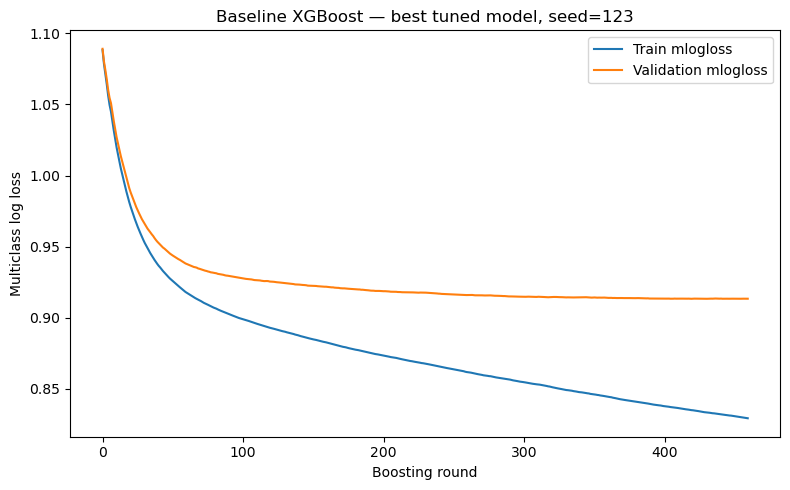

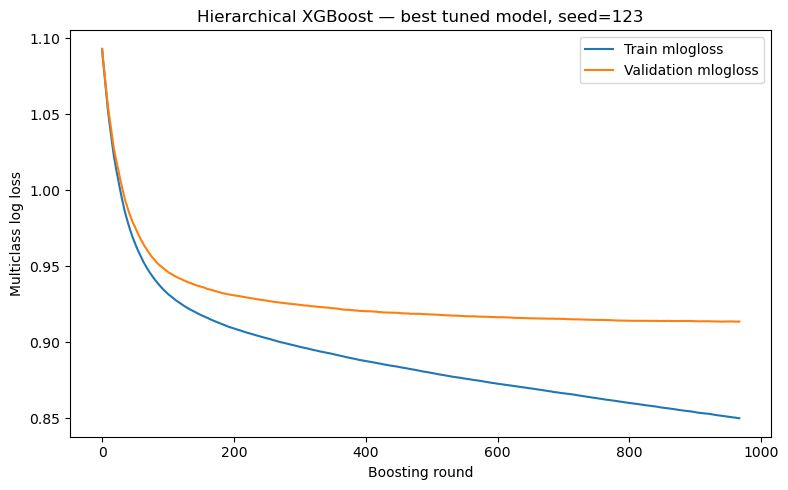

In [20]:
# learning curves for the last seed 

REP_SEED = SEEDS[-1]

plot_xgb_learning_curve(
    fitted_runs[REP_SEED]["baseline_best_tuned_model"],
    title=f"Baseline XGBoost — best tuned model, seed={REP_SEED}"
)

plot_xgb_learning_curve(
    fitted_runs[REP_SEED]["hier_best_tuned_model"],
    title=f"Hierarchical XGBoost — best tuned model, seed={REP_SEED}"
)

The learning curves decrease smoothly for both models, suggesting that the XGBoost optimization behaves normally. The validation loss remains above the training loss, which is expected, but the gap is not extreme.

In [21]:
# validation results for the last seed
baseline_val_results, _, _ = evaluate_model_on_split(
    fitted_runs[REP_SEED]["baseline_best_tuned_model"],
    fitted_runs[REP_SEED]["baseline_tuned_preprocessor"],
    X_val_baseline,
    y_val,
    baseline_features_cols,
    split_name=f"validation_seed_{REP_SEED}"
)

hierarchical_val_results, _, _ = evaluate_model_on_split(
    fitted_runs[REP_SEED]["hier_best_tuned_model"],
    fitted_runs[REP_SEED]["hier_tuned_preprocessor"],
    X_val_hierarchical,
    y_val,
    hierarchical_features_cols,
    split_name=f"validation_seed_{REP_SEED}"
)

display(pd.DataFrame([baseline_val_results]))
display(pd.DataFrame([hierarchical_val_results]))

,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation_seed_123,0.567292,0.517056,0.563824,0.521046,0.42526,0.913261


,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,validation_seed_123,0.564745,0.514519,0.560811,0.524933,0.423074,0.913562


In [22]:
# confusion matrices for one representative seed

class_labels = ["difficulty", "moderate_success", "strong_success"]

# Baseline
baseline_test_results_rep = evaluate_predictions(
    y_test,
    fitted_runs[REP_SEED]["baseline_test_pred"],
    fitted_runs[REP_SEED]["baseline_test_prob"],
    split_name=f"test_seed_{REP_SEED}"
)

cm_baseline = confusion_matrix(
    y_test,
    fitted_runs[REP_SEED]["baseline_test_pred"],
    labels=[0, 1, 2]
)

cm_baseline_df = pd.DataFrame(
    cm_baseline,
    index=[f"true_{c}" for c in class_labels],
    columns=[f"pred_{c}" for c in class_labels]
)

print(f"Baseline model, representative seed = {REP_SEED}")
display(pd.DataFrame([baseline_test_results_rep]))
display(cm_baseline_df)

# Hierarchical
hier_test_results_rep = evaluate_predictions(
    y_test,
    fitted_runs[REP_SEED]["hier_test_pred"],
    fitted_runs[REP_SEED]["hier_test_prob"],
    split_name=f"test_seed_{REP_SEED}"
)

cm_hier = confusion_matrix(
    y_test,
    fitted_runs[REP_SEED]["hier_test_pred"],
    labels=[0, 1, 2]
)

cm_hier_df = pd.DataFrame(
    cm_hier,
    index=[f"true_{c}" for c in class_labels],
    columns=[f"pred_{c}" for c in class_labels]
)

print(f"Hierarchical model, representative seed = {REP_SEED}")
display(pd.DataFrame([hier_test_results_rep]))
display(cm_hier_df)

Baseline model, representative seed = 123


,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,test_seed_123,0.549122,0.511367,0.558167,0.557566,0.419686,0.930402


,pred_difficulty,pred_moderate_success,pred_strong_success
true_difficulty,749,269,124
true_moderate_success,932,899,682
true_strong_success,672,685,2449


Hierarchical model, representative seed = 123


,split,accuracy,macro_f1,weighted_f1,mae_on_ordered_labels,quadratic_weighted_kappa,log_loss
0,test_seed_123,0.552473,0.51563,0.562331,0.558236,0.419932,0.930198


,pred_difficulty,pred_moderate_success,pred_strong_success
true_difficulty,770,251,121
true_moderate_success,952,908,653
true_strong_success,705,657,2444


Both models predict the strong-success class best, which is expected because it is the most frequent class. However, the confusion matrices show that the "moderate success" class is the most difficult to classify for both models, with a majority of true moderate-success entries predicted as either difficulty or strong success. This makes sense because the middle class is less clearly separated from the two extremes. The hierarchical model slightly improves the overall metrics, but the confusion matrices remain very similar, showing that the added sibling-history features do not fundamentally change the model’s prediction behavior.

# 5) Comparison between the two models

For comparison between the two models (to answer the question "does the hierarchy model outperform the baseline model"), we use:

- the difference between the two macro F1 scores
- the difference between the two QWK
- the difference between the two log loss

In [23]:
# --- comparison of the 2 models across seeds ---

seed_results_df = pd.DataFrame(all_seed_results)
display(seed_results_df)

# Baseline vs hierarchical side by side per seed, with deltas
pivot = seed_results_df.pivot(
    index="seed", columns="model",
    values=["macro_f1", "quadratic_weighted_kappa", "log_loss"]
)
pivot.columns = [f"{col[1]}_{col[0]}" for col in pivot.columns]
pivot["delta_macro_f1"] = pivot["hierarchical_macro_f1"] - pivot["baseline_macro_f1"]
pivot["delta_kappa"]    = pivot["hierarchical_quadratic_weighted_kappa"] - pivot["baseline_quadratic_weighted_kappa"]
display(pivot.round(4))

# Mean ± std across seeds
summary = seed_results_df.groupby("model")[["macro_f1", "quadratic_weighted_kappa", "log_loss"]].agg(["mean", "std"])
print("\nMean ± std across 3 seeds:")
display(summary.round(4))

,seed,model,macro_f1,quadratic_weighted_kappa,log_loss,best_params,best_iteration
0,42,baseline,0.511978,0.419748,0.928238,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",756
1,42,hierarchical,0.515575,0.422708,0.930590,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",338
2,0,baseline,0.511143,0.417159,0.931997,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",465
3,0,hierarchical,0.515948,0.422671,0.929023,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",952
4,123,baseline,0.511367,0.419686,0.930402,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",429
5,123,hierarchical,0.515630,0.419932,0.930198,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",937


,baseline_macro_f1,hierarchical_macro_f1,baseline_quadratic_weighted_kappa,hierarchical_quadratic_weighted_kappa,baseline_log_loss,hierarchical_log_loss,delta_macro_f1,delta_kappa
seed,,,,,,,,
0,0.5111,0.5159,0.4172,0.4227,0.9320,0.9290,0.0048,0.0055
42,0.5120,0.5156,0.4197,0.4227,0.9282,0.9306,0.0036,0.0030
123,0.5114,0.5156,0.4197,0.4199,0.9304,0.9302,0.0043,0.0002



Mean ± std across 3 seeds:


macro_f1         quadratic_weighted_kappa         log_loss  \
                 mean     std                     mean     std     mean   
model                                                                     
baseline       0.5115  0.0004                   0.4189  0.0015   0.9302   
hierarchical   0.5157  0.0002                   0.4218  0.0016   0.9299   

                      
                 std  
model                 
baseline      0.0019  
hierarchical  0.0008

We observe a **very small but consistent increase in macro-F1 and QWK for the hierarchical model** compared with the baseline. Log-loss changes only marginally and is not consistently improved across all seeds. Therefore, the main evidence for a benefit of the hierarchical model comes from macro-F1 and QWK.

# 6) Feature importance analysis

We now study feature importance to understand whether the added sibling-history features are actually used by the model and whether they contribute signal beyond the baseline features or not (as the metrics are suggesting).

,feature,importance
73,num__subject_math,0.312854
1,cat__child_topic_id_951.0,0.037541
49,cat__child_topic_id_3110.0,0.031148
52,cat__child_topic_id_3113.0,0.028726
51,cat__child_topic_id_3112.0,0.027919
69,cat__child_topic_id_3320.0,0.026707
46,cat__child_topic_id_2055.0,0.024577
24,cat__child_topic_id_1007.0,0.019319
47,cat__child_topic_id_2064.0,0.018277
3,cat__child_topic_id_956.0,0.017868


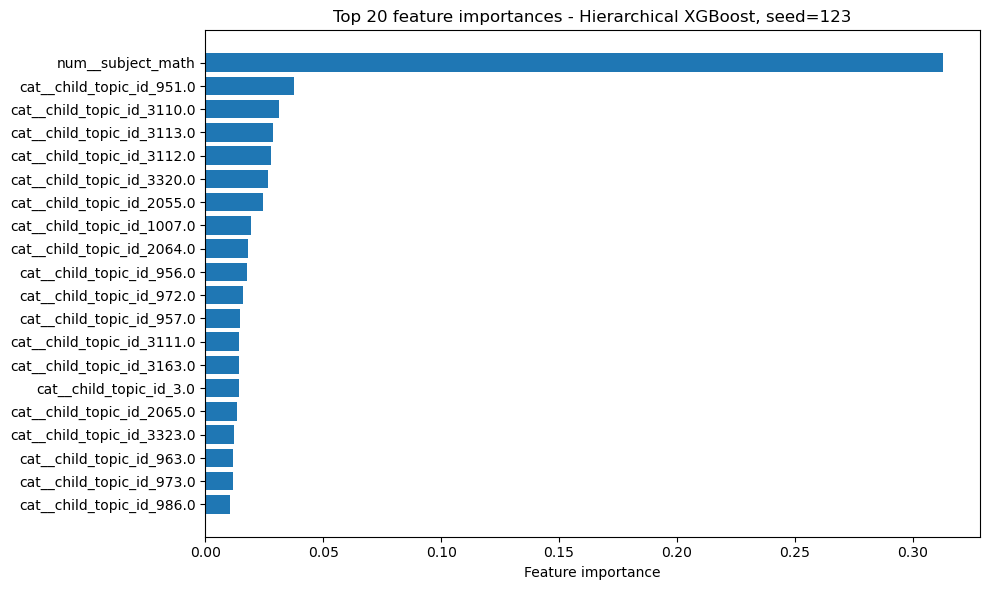

In [24]:
# feature importance of the hierarchical model

hier_preprocessor_for_importance = fitted_runs[REP_SEED]["hier_final_preprocessor"]
hier_model_for_importance = fitted_runs[REP_SEED]["hier_final_model"]

feature_names_hier = hier_preprocessor_for_importance.get_feature_names_out()

importances = pd.DataFrame({
    "feature": feature_names_hier,
    "importance": hier_model_for_importance.feature_importances_
}).sort_values("importance", ascending=False)

display(importances.head(20))

plt.figure(figsize=(10, 6))
top20 = importances.head(20)
plt.barh(top20["feature"][::-1], top20["importance"][::-1])
plt.xlabel("Feature importance")
plt.title(f"Top 20 feature importances - Hierarchical XGBoost, seed={REP_SEED}")
plt.tight_layout()
plt.show()

The dominant feature is subject_math, suggesting that the subject itself is the strongest predictor of entry success (students entering math topics perform differently from those entering German topics at a global level). Below that, individual child_topic_id features collectively dominate the remaining importance mass, reflecting strong topic-specific difficulty effects. This is plausible because different child topics likely differ in several important ways, such as in:

- their intrinsic difficulty
- their style/format of questions
- the type of students typically reaching them
- and, more generally, how “easy” it is to get 0/3, 2/3, or 3/3 correct on first entry into the topic

In other words, the model appears to learn that some topics are inherently more likely than others to lead to difficulty, moderate success, or strong success at entry.

In [25]:
# Get feature names from the fitted hierarchical preprocessor

# Keep only sibling-related features
sibling_importances = importances[
    importances["feature"].str.contains("sibling", case=False, na=False)
].copy()

print("Sibling feature importances:")
display(sibling_importances)

Sibling feature importances:


,feature,importance
84,num__prior_sibling_accuracy,0.004406
89,num__prop_sibling_topics_entered_before,0.003978
90,num__is_first_topic_in_sibling_group,0.003933
88,num__prior_sibling_accuracy_30d,0.003624
86,num__prop_siblings_seen,0.003456
92,num__n_prior_sibling_attempts_last3,0.003429
83,num__n_prior_sibling_attempts,0.002916
87,num__n_prior_sibling_attempts_30d,0.002902
85,num__days_since_last_sibling_activity,0.002838
93,num__recent_sibling_accuracy_trend,0.002755


None of the sibling-based features appear in the top 20 most important features. All sibling-history features have importances below **0.005**, meaning that each contributes less than 0.5% of the normalized feature-importance mass.

The largest sibling-related importances are `prior_sibling_accuracy`, `prop_sibling_topics_entered_before`, and `is_first_topic_in_sibling_group`, but their values remain very small compared with `subject_math` and the one-hot encoded `child_topic_id` features.

This suggests that sibling history may contribute a weak additional signal, but it is much less important than subject identity, topic identity and general prior-history features.

In [26]:
# Inspect sibling groups: parent topic + nb of child topics in the group

all_groups = (
    lookup_table.groupby(["parent_id", "parent_name"])
    .size()
    .reset_index(name="n_topics_in_group")
    .sort_values("n_topics_in_group", ascending=False)
)

display(all_groups.head(20))
print(all_groups.shape)

,parent_id,parent_name,n_topics_in_group
3,985.0,Equations,10
1,950.0,Numbers and number sets,9
2,969.0,Terms,6
7,1058.0,Trigonometry,6
12,3107.0,Sets,6
4,1006.0,Functions,5
5,1030.0,Elementary geometry,5
10,3105.0,Word types,5
0,2.0,Orthography,4
8,2022.0,Vocabulary and stylistics,4


(14, 3)


# 7) Explore selection bias

The hierarchical model tests whether sibling-topic history adds predictive signal beyond baseline features. It does not prove that practicing sibling topics causally improves performance on the target topic. The selection-bias concern is that students with sibling-topic history are not randomly comparable to students without sibling-topic history. They may be more motivated, more persistent, more advanced, more interested in that topic branch, or following a specific teacher/platform path. In other words, some sibling-history features may reflect non-random student behavior.

There are at least three possible selection mechanisms:

1. **Student selection:** some students are more active, motivated, or strategic, so they accumulate more sibling history before entering new topics.
2. **Topic selection:** some topics may attract students who prepare more, while others are entered directly.
3. **Survivorship selection:** because the target is based on the first three answered questions, students who abandon a topic after one or two questions are excluded.

These mechanisms can make sibling-history features look useful even if the effect is partly due to who chooses which topics, rather than transfer of learning itself.

In [27]:
entry_model_df["has_sibling_history"] = (
    entry_model_df["n_prior_sibling_attempts"] > 0
).astype(int)

entry_model_df["entry_type"] = np.where(
    entry_model_df["has_sibling_history"] == 1,
    "prepared_entry",
    "direct_entry"
)

display(entry_model_df["entry_type"].value_counts(normalize=True).rename("proportion"))

entry_type
direct_entry      0.515613
prepared_entry    0.484387
Name: proportion, dtype: float64

### 1) Compare "prepared-entry" and "direct-entry" users

This checks whether students with sibling history are already different before entering the target topic.

In [28]:
cols_to_compare = [
    "n_prior_answered_questions",
    "prior_global_accuracy",
    "n_prior_active_weeks",
    "n_prior_topics_seen",
    "n_prior_topics_same_subject",
    "n_prior_answered_same_subject",
    "prior_subject_accuracy",
    "days_since_last_activity",
    "days_since_last_same_subject_activity",
]

group_comparison = (
    entry_model_df
    .groupby("entry_type")[cols_to_compare]
    .mean()
    .round(3)
)

display(group_comparison)

,n_prior_answered_questions,prior_global_accuracy,n_prior_active_weeks,n_prior_topics_seen,n_prior_topics_same_subject,n_prior_answered_same_subject,prior_subject_accuracy,days_since_last_activity,days_since_last_same_subject_activity
entry_type,,,,,,,,,
direct_entry,20.254,0.391,0.904,2.027,1.468,15.279,0.322,18.904,13.539
prepared_entry,53.046,0.794,1.875,5.145,4.492,47.728,0.795,6.823,7.331


Prepared-entry and direct-entry users differ substantially before entering the target topic. **Prepared-entry users have answered more prior questions, seen more topics, have more active weeks and show higher prior accuracy.** This means sibling-history exposure is not random: it is associated with broader user activity and prior performance. One caveat to keep in mind is that missing prior accuracy is also filled with 0, so part of the accuracy difference also reflects the fact that many direct-entry users have little or no prior history. Overall, any **predictive advantage of sibling-history features may partly reflect selection bias** rather than a causal transfer effect.

In [29]:
def standardized_mean_difference(df, group_col, cols):
    rows = []

    group_0 = df[df[group_col] == "direct_entry"]
    group_1 = df[df[group_col] == "prepared_entry"]

    for col in cols:
        m0 = group_0[col].mean()
        m1 = group_1[col].mean()
        s0 = group_0[col].std()
        s1 = group_1[col].std()

        pooled_sd = np.sqrt((s0**2 + s1**2) / 2)

        if pooled_sd == 0 or np.isnan(pooled_sd):
            smd = np.nan
        else:
            smd = (m1 - m0) / pooled_sd

        rows.append({
            "feature": col,
            "mean_direct_entry": m0,
            "mean_prepared_entry": m1,
            "standardized_mean_difference": smd,
            "abs_smd": abs(smd)
        })

    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)

smd_table = standardized_mean_difference(
    entry_model_df,
    group_col="entry_type",
    cols=cols_to_compare
)

display(smd_table.round(3))

,feature,mean_direct_entry,mean_prepared_entry,standardized_mean_difference,abs_smd
6,prior_subject_accuracy,0.322,0.795,1.485,1.485
1,prior_global_accuracy,0.391,0.794,1.257,1.257
4,n_prior_topics_same_subject,1.468,4.492,0.839,0.839
3,n_prior_topics_seen,2.027,5.145,0.750,0.750
5,n_prior_answered_same_subject,15.279,47.728,0.480,0.480
0,n_prior_answered_questions,20.254,53.046,0.454,0.454
2,n_prior_active_weeks,0.904,1.875,0.418,0.418
7,days_since_last_activity,18.904,6.823,-0.274,0.274
8,days_since_last_same_subject_activity,13.539,7.331,-0.157,0.157


The standardized mean differences confirm substantial imbalance between direct-entry and prepared-entry students, especially for accuracy measures:

- `prior_subject_accuracy`: SMD = **1.485**
- `prior_global_accuracy`: SMD = **1.257**

Several experience-related variables also show clear imbalance, such as the number of prior topics seen and the number of prior same-subject topics. Recency variables show smaller but still meaningful differences.

By conventional thresholds, |SMD| > 0.1 indicates imbalance and |SMD| > 0.5 indicates substantial imbalance. These results confirm that students with sibling history are not directly comparable to students without sibling history. Therefore, any association between sibling history and entry success is heavily confounded, and causal interpretation is not warranted.

### 2) Check topic-level routing patterns

In [30]:
topic_selection = (
    entry_model_df
    .groupby("child_topic_id")
    .agg(
        n_entries=("user_id", "size"),
        frac_with_sibling_history=("has_sibling_history", "mean"),
        mean_target_code=("target_code", "mean"),
        mean_prior_global_accuracy=("prior_global_accuracy", "mean"),
        mean_prior_subject_accuracy=("prior_subject_accuracy", "mean"),
    )
    .reset_index()
    .sort_values("frac_with_sibling_history", ascending=False)
)

display(topic_selection)

,child_topic_id,n_entries,frac_with_sibling_history,mean_target_code,mean_prior_global_accuracy,mean_prior_subject_accuracy
68,3319.0,939,0.908413,1.739084,0.835788,0.846594
4,957.0,462,0.904762,0.547619,0.673133,0.651675
58,3154.0,106,0.896226,1.575472,0.842599,0.844571
70,3323.0,1751,0.883495,1.390634,0.817407,0.824149
6,962.0,456,0.881579,1.144737,0.653795,0.626381
...,...,...,...,...,...,...
42,2023.0,1068,0.106742,1.551498,0.623480,0.610140
33,1041.0,443,0.097065,1.347630,0.569676,0.408469
36,1059.0,511,0.095890,1.187867,0.433912,0.373557
56,3141.0,355,0.092958,1.800000,0.723837,0.714156


In [31]:
if "lookup_table" in globals() and "child_name" in lookup_table.columns:
    topic_selection_named = topic_selection.merge(
        lookup_table[["child_topic_id", "child_name"]].drop_duplicates(),
        on="child_topic_id",
        how="left"
    )
    display(topic_selection_named)

,child_topic_id,n_entries,frac_with_sibling_history,mean_target_code,mean_prior_global_accuracy,mean_prior_subject_accuracy,child_name
0,3319.0,939,0.908413,1.739084,0.835788,0.846594,Comma in direct speech and quotations
1,957.0,462,0.904762,0.547619,0.673133,0.651675,Fractions ↔ Decimal fractions
2,3154.0,106,0.896226,1.575472,0.842599,0.844571,Structure of clauses
3,3323.0,1751,0.883495,1.390634,0.817407,0.824149,Comma for additions
4,962.0,456,0.881579,1.144737,0.653795,0.626381,Round decimal fractions
...,...,...,...,...,...,...,...
68,2023.0,1068,0.106742,1.551498,0.623480,0.610140,Vocabulary
69,1041.0,443,0.097065,1.347630,0.569676,0.408469,Vectors
70,1059.0,511,0.095890,1.187867,0.433912,0.373557,"Sine, Cosine, Tangent - Definition"
71,3141.0,355,0.092958,1.800000,0.723837,0.714156,Function of the sentence elements


The **proportion of entries with sibling history varies strongly by child topic**. Some topics are usually entered after sibling practice, while others are mostly entered directly. This suggests that sibling exposure also depends on topic-level routing patterns, not only on student-level behavior. As a result, sibling-history features may partly encode topic/course pathways rather than pure transfer of learning.

### 3) Check student-level specialization

This explores whether some students focus mainly on specific subjects or topic branches.

,user_id,n_entries,n_child_topics,n_parent_branches,mean_has_sibling_history,math_entry_share,parent_entropy,child_topic_entropy
count,14938.000,14938.000,14938.000,14938.000,14938.000,14938.000,14938.000,14938.000
mean,406909.298,3.329,3.329,1.852,0.313,0.398,0.434,0.636
std,11357.251,3.465,3.465,1.238,0.314,0.457,0.467,0.481
min,387604.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000
25%,397410.250,1.000,1.000,1.000,0.000,0.000,0.000,0.000
50%,405438.000,2.000,2.000,1.000,0.333,0.000,0.000,1.000
75%,414363.750,4.000,4.000,2.000,0.571,1.000,0.943,1.000
max,432020.000,40.000,40.000,12.000,1.000,1.000,1.000,1.000


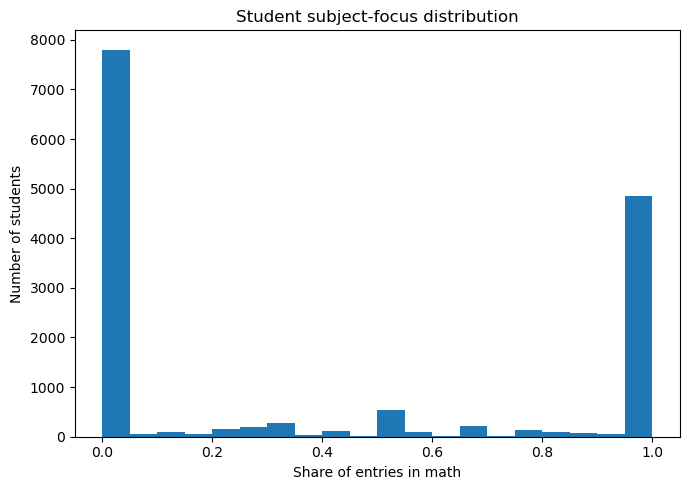

In [32]:
def normalized_entropy(s):
    counts = s.value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    return -(counts * np.log(counts)).sum() / np.log(len(counts))

student_focus = (
    entry_model_df
    .groupby("user_id")
    .agg(
        n_entries=("child_topic_id", "size"),
        n_child_topics=("child_topic_id", "nunique"),
        n_parent_branches=("parent_id", "nunique"),
        mean_has_sibling_history=("has_sibling_history", "mean"),
        math_entry_share=("subject_math", "mean"),
        parent_entropy=("parent_id", normalized_entropy),
        child_topic_entropy=("child_topic_id", normalized_entropy),
    )
    .reset_index()
)

display(student_focus.describe().round(3))

plt.figure(figsize=(7, 5))
plt.hist(student_focus["math_entry_share"], bins=20)
plt.xlabel("Share of entries in math")
plt.ylabel("Number of students")
plt.title("Student subject-focus distribution")
plt.tight_layout()
plt.show()

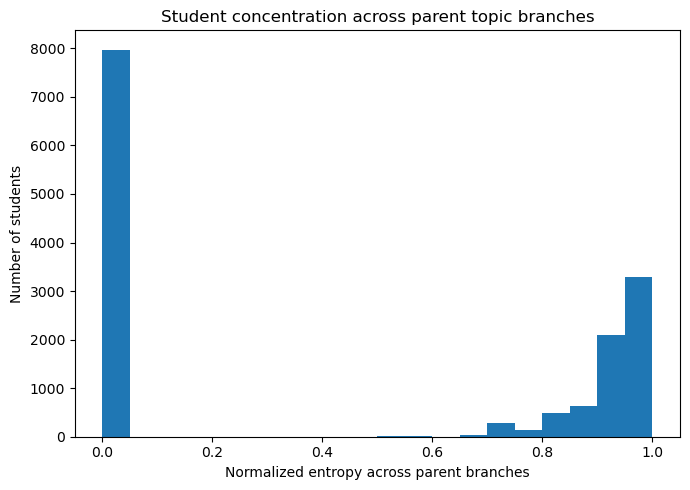

In [33]:
plt.figure(figsize=(7, 5))
plt.hist(student_focus["parent_entropy"], bins=20)
plt.xlabel("Normalized entropy across parent branches")
plt.ylabel("Number of students")
plt.title("Student concentration across parent topic branches")
plt.tight_layout()
plt.show()

Most users have very few retained entry events, with a median of only 2 child topics per user. Many students also concentrate on a single subject or a small number of parent branches, as shown by the subject-share and entropy distributions. This limited and specialized activity makes it harder to distinguish genuine learning transfer from user specialization or curriculum navigation patterns.

### 4) Propensity-style analysis: can we predict sibling exposure?

This checks whether sibling exposure is predictable from baseline variables.

The propensity model is evaluated using the same chronological logic as the main prediction task: earlier entries were used for training and later entries for testing. This avoids using future entries to estimate how predictable sibling exposure is.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

propensity_features = [
    "n_prior_answered_questions",
    "prior_global_accuracy",
    "n_prior_active_weeks",
    "n_prior_topics_seen",
    "n_prior_topics_same_subject",
    "n_prior_answered_same_subject",
    "prior_subject_accuracy",
    "days_since_last_activity",
    "days_since_last_same_subject_activity",
    "subject_math",
    "n_active_siblings",
]

# we use the same chronological split logic as the main models.
propensity_df = entry_model_df[
    propensity_features + ["has_sibling_history", "entry_start_time"]
].copy()
propensity_df = propensity_df.sort_values("entry_start_time").reset_index(drop=True)

split_idx = int(0.85 * len(propensity_df)) # 70% train + 15% validation = 85% / 15% test

X_prop_train = propensity_df.iloc[:split_idx][propensity_features].fillna(0)
X_prop_test  = propensity_df.iloc[split_idx:][propensity_features].fillna(0)
y_prop_train = propensity_df.iloc[:split_idx]["has_sibling_history"].astype(int)
y_prop_test  = propensity_df.iloc[split_idx:]["has_sibling_history"].astype(int)

print("Propensity train rows:", len(X_prop_train))
print("Propensity test rows:", len(X_prop_test))

print("\nSibling-history rate:")
print("Train:", round(y_prop_train.mean(), 3))
print("Test:", round(y_prop_test.mean(), 3))

assert y_prop_train.nunique() == 2, "Training set contains only one propensity class."
assert y_prop_test.nunique() == 2, "Test set contains only one propensity class."


propensity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

propensity_model.fit(X_prop_train, y_prop_train)

propensity_scores = propensity_model.predict_proba(X_prop_test)[:, 1]

print("AUC for predicting sibling exposure:",
      round(roc_auc_score(y_prop_test, propensity_scores), 3))

print("Average precision:",
      round(average_precision_score(y_prop_test, propensity_scores), 3))

Propensity train rows: 42274
Propensity test rows: 7461

Sibling-history rate:
Train: 0.478
Test: 0.52
AUC for predicting sibling exposure: 0.81
Average precision: 0.771


The logistic regression predicts sibling exposure with **AUC = 0.810** and **average precision = 0.771** on the chronological test set, from baseline variables alone. This shows that **"having sibling history" is not random but is strongly predictable from baseline student characteristics** such as prior activity, prior accuracy, subject and the number of active siblings. In other words, sibling exposure is not random: prepared-entry and direct-entry observations already differ before the target topic entry. This supports the selection-bias interpretation and reinforces that sibling-history effects should be interpreted as predictive associations rather than causal evidence of transfer of learning.

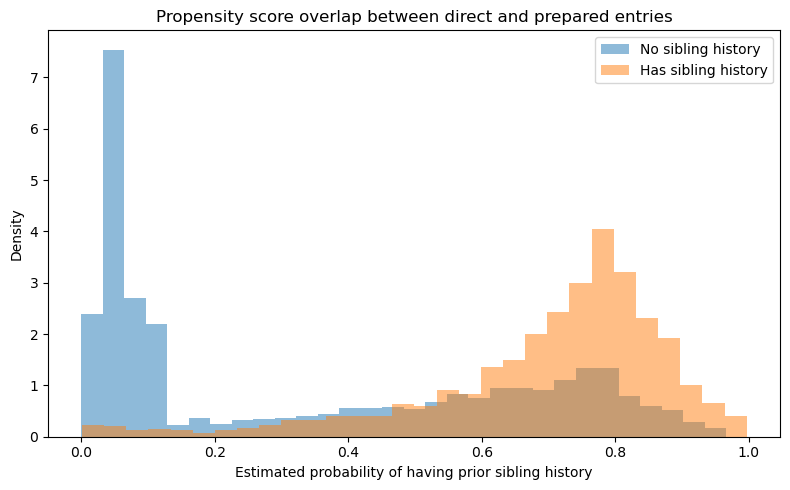

In [38]:
# plot overlap

propensity_plot_df = propensity_df.iloc[split_idx:][
    ["entry_start_time", "has_sibling_history"]
].copy()
propensity_plot_df["propensity_score"] = propensity_scores

plt.figure(figsize=(8, 5))

for group, label in [(0, "No sibling history"), (1, "Has sibling history")]:
    plt.hist(
        propensity_plot_df.loc[
            propensity_plot_df["has_sibling_history"] == group,
            "propensity_score"
        ],
        bins=30,
        alpha=0.5,
        density=True,
        label=label
    )

plt.xlabel("Estimated probability of having prior sibling history")
plt.ylabel("Density")
plt.title("Propensity score overlap between direct and prepared entries")
plt.legend()
plt.tight_layout()
plt.show()

The propensity score overlap plot shows **clear separation between the two groups**. Entries with sibling history tend to have higher propensity scores, while entries without sibling history are concentrated at lower scores. There is some overlap, but the common-support region is limited.

This means that direct-entry and prepared-entry observations are not fully comparable. Therefore, estimating a causal effect of sibling practice would require additional causal-inference methods, such as matching, weighting or doubly robust estimation. In this notebook, the result should be interpreted as evidence of selection bias, not as a causal estimate.

### 5) Check whether model improvement is subgroup-specific

This tells whether the hierarchical model helps generally, or only for certain students/topics.

In [39]:
subgroup_eval_df = test_df.copy()
subgroup_eval_df["y_true"] = y_test.values
subgroup_eval_df["baseline_pred"] = fitted_runs[REP_SEED]["baseline_test_pred"]
subgroup_eval_df["hier_pred"] = fitted_runs[REP_SEED]["hier_test_pred"]
subgroup_eval_df["has_sibling_history"] = (
    subgroup_eval_df["n_prior_sibling_attempts"] > 0
).astype(int)

def subgroup_metrics(df, group_col, min_n=100):
    rows = []

    for group_value, g in df.groupby(group_col):
        if len(g) < min_n:
            continue

        baseline_f1 = f1_score(g["y_true"], g["baseline_pred"], average="macro")
        hier_f1 = f1_score(g["y_true"], g["hier_pred"], average="macro")

        baseline_qwk = cohen_kappa_score(
            g["y_true"],
            g["baseline_pred"],
            weights="quadratic"
        )

        hier_qwk = cohen_kappa_score(
            g["y_true"],
            g["hier_pred"],
            weights="quadratic"
        )

        rows.append({
            "group_variable": group_col,
            "group_value": group_value,
            "n": len(g),
            "baseline_macro_f1": baseline_f1,
            "hierarchical_macro_f1": hier_f1,
            "delta_macro_f1": hier_f1 - baseline_f1,
            "baseline_qwk": baseline_qwk,
            "hierarchical_qwk": hier_qwk,
            "delta_qwk": hier_qwk - baseline_qwk,
        })

    return pd.DataFrame(rows).sort_values("delta_macro_f1", ascending=False)

display(subgroup_metrics(subgroup_eval_df, "subject_math"))
display(subgroup_metrics(subgroup_eval_df, "has_sibling_history"))
display(subgroup_metrics(subgroup_eval_df, "is_first_topic_in_sibling_group"))
display(subgroup_metrics(subgroup_eval_df, "parent_id"))

,group_variable,group_value,n,baseline_macro_f1,hierarchical_macro_f1,delta_macro_f1,baseline_qwk,hierarchical_qwk,delta_qwk
0,subject_math,0,4371,0.489886,0.504587,0.014701,0.346015,0.359422,0.013408
1,subject_math,1,3090,0.439557,0.431900,-0.007657,0.273915,0.256159,-0.017756


,group_variable,group_value,n,baseline_macro_f1,hierarchical_macro_f1,delta_macro_f1,baseline_qwk,hierarchical_qwk,delta_qwk
1,has_sibling_history,1,3882,0.518663,0.526440,0.007778,0.428110,0.425953,-0.002157
0,has_sibling_history,0,3579,0.503653,0.504285,0.000631,0.411063,0.413780,0.002717


,group_variable,group_value,n,baseline_macro_f1,hierarchical_macro_f1,delta_macro_f1,baseline_qwk,hierarchical_qwk,delta_qwk
0,is_first_topic_in_sibling_group,0,3538,0.520774,0.528349,0.007575,0.431589,0.430619,-0.000969
1,is_first_topic_in_sibling_group,1,3923,0.503232,0.504720,0.001488,0.409504,0.410850,0.001346


,group_variable,group_value,n,baseline_macro_f1,hierarchical_macro_f1,delta_macro_f1,baseline_qwk,hierarchical_qwk,delta_qwk
11,parent_id,3106.0,164,0.468070,0.529140,0.061070,0.486456,0.539537,0.053081
8,parent_id,2022.0,308,0.361580,0.386275,0.024694,0.184738,0.209704,0.024966
4,parent_id,1006.0,472,0.476895,0.481603,0.004708,0.383466,0.367275,-0.016191
10,parent_id,3105.0,1194,0.431426,0.434696,0.003270,0.312251,0.328651,0.016400
0,parent_id,2.0,1252,0.320886,0.322445,0.001559,0.033951,0.026699,-0.007251
5,parent_id,1030.0,174,0.404106,0.402575,-0.001531,0.175277,0.150764,-0.024514
3,parent_id,985.0,480,0.310170,0.306731,-0.003438,0.066841,0.063076,-0.003765
9,parent_id,3104.0,1336,0.420983,0.415112,-0.005871,0.247842,0.236263,-0.011579
1,parent_id,950.0,889,0.493400,0.484756,-0.008644,0.378828,0.362072,-0.016757
2,parent_id,969.0,700,0.338924,0.325041,-0.013882,0.097602,0.081407,-0.016195


The **hierarchical model's improvement is not uniform across subgroups**.

- For **German topics** (`subject_math = 0`), the hierarchical model improves performance: ΔF1 = **+0.0147** and ΔQWK = **+0.0134**.
- For **Math topics** (`subject_math = 1`), the hierarchical model performs slightly worse: ΔF1 = **−0.0077** and ΔQWK = **−0.0178**.

The subgroup analysis by sibling-history status shows that the hierarchical model improves macro-F1 more for entries with prior sibling history than for direct entries. However, QWK slightly decreases for entries with sibling history and only slightly increases for direct entries. This confirms that the model improvement depends on the metric and should be interpreted cautiously.

Similarly, the improvement is small when comparing entries that are the first topic in a sibling group versus later entries within the same sibling group.

The effect also varies strongly across parent branches. The largest positive QWK improvements appear for:

- `Sentence links` (`parent_id = 3106`): ΔQWK = **+0.0531**
- `Vocabulary and stylistics` (`parent_id = 2022`): ΔQWK = **+0.0250**
- `Word types` (`parent_id = 3105`): ΔQWK = **+0.0164**

However, several branches show degradation, for example:

- `Similarity geometry` (`parent_id = 1045`): ΔQWK = **−0.0800**
- `Elementary geometry` (`parent_id = 1030`): ΔQWK = **−0.0245**
- `Numbers and number sets` (`parent_id = 950`): ΔQWK = **−0.0168**

This heterogeneity suggests that sibling history is informative only for some topic groups. The aggregate improvement therefore hides branch-specific differences, with some branches benefiting from sibling-history features and others not.

## Final takeaway

Overall, sibling-history features provide a small and consistent predictive improvement over the baseline model, but the effect is weak. The results suggest that some hierarchical learning signal may exist in the transaction data, but it is much smaller than topic-specific and student-history effects. Because sibling exposure is strongly associated with prior activity, prior accuracy and topic routing patterns, these results should be interpreted as predictive evidence rather than causal proof of transfer of learning.